MULTI-RUN MIGRATION ANALYSIS
Runs: auto-discovered from filesystem (missing files skipped)
Auto-discovered runs for LLAMA - wanda: ['Run0.25_5']

Processing: LLAMA - wanda (1 runs)
/workspace/CCE_NLI/LLAMA/exp/wanda/Run0.25_5/Expls/0.0%Pruned/Cluster1IOUS1024N.csv
/workspace/CCE_NLI/LLAMA/exp/wanda/Run0.25_5/Expls/0.0%Pruned/Cluster2IOUS1024N.csv
/workspace/CCE_NLI/LLAMA/exp/wanda/Run0.25_5/Expls/0.0%Pruned/Cluster3IOUS1024N.csv
Comparing /workspace/CCE_NLI/LLAMA/exp/wanda/Run0.25_5/Expls/0.0%Pruned/Cluster1IOUS1024N.csv
Comparing /workspace/CCE_NLI/LLAMA/exp/wanda/Run0.25_5/Expls/0.0%Pruned/Cluster2IOUS1024N.csv
Comparing /workspace/CCE_NLI/LLAMA/exp/wanda/Run0.25_5/Expls/0.0%Pruned/Cluster3IOUS1024N.csv
concepts common to sparse, dense, pretrained 288
concepts common to dense, pretrained 288
concepts between sparse and (dense that are not in pretrained) = 118
concets in dense not in pretrained 118
concepts between sparse and (pretrained that are not in dense) = 0
num SPARSE concepts 

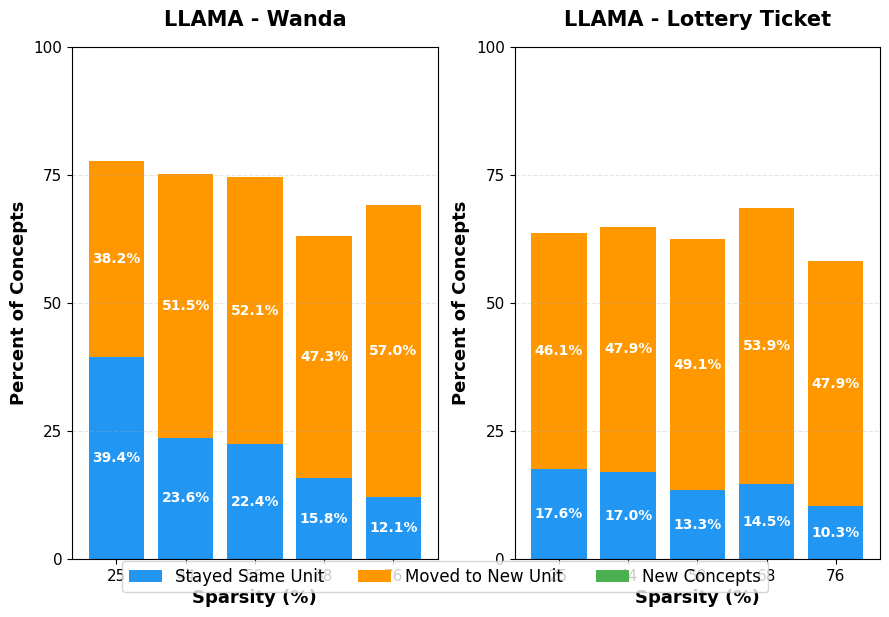

Concept migration plot for Cluster2 saved to 'averaged_multi_model_concept_migration_Cluster2.png'


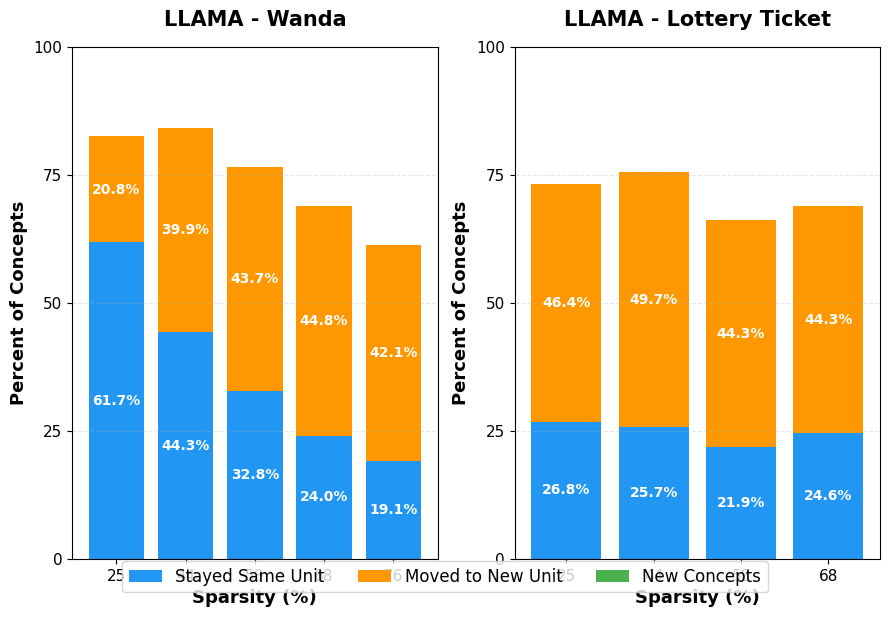

Concept migration plot for Cluster3 saved to 'averaged_multi_model_concept_migration_Cluster3.png'


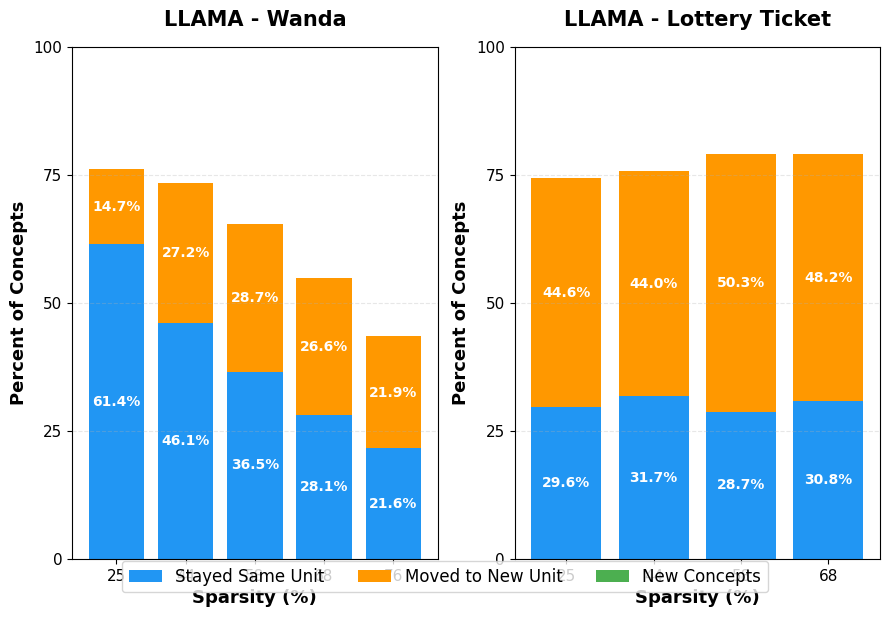


GENERATING CROSS-CLUSTER MIGRATION PLOTS (AVERAGED)
Cross-cluster migration plot saved to 'averaged_multi_model_cross_cluster_migration.png'


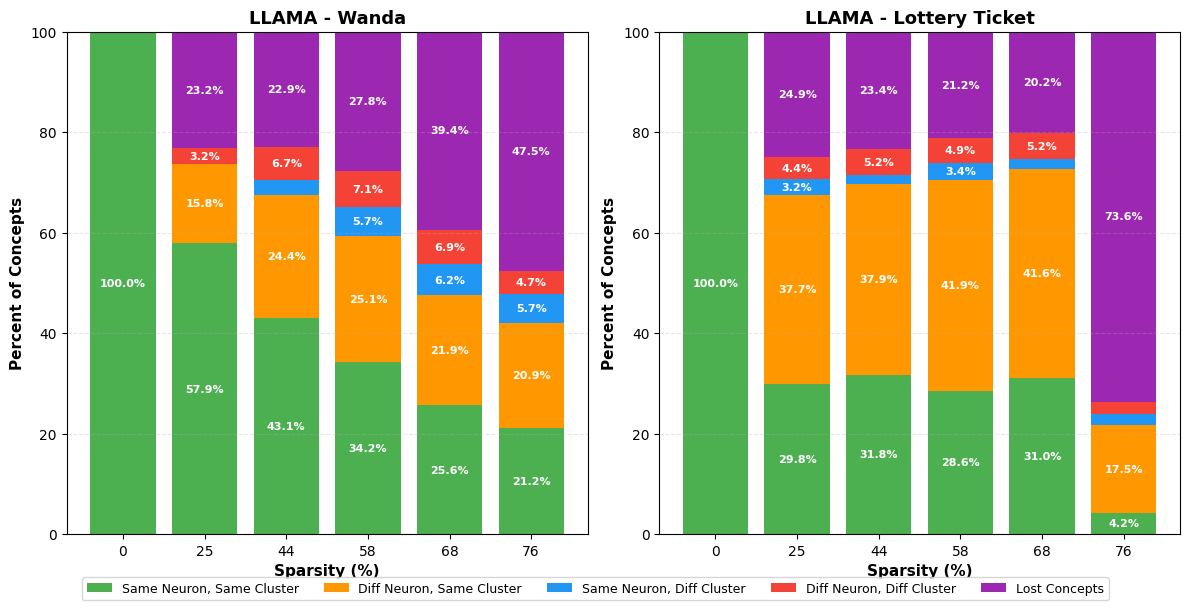

Lost concepts plot saved to 'averaged_lost_concepts.png'


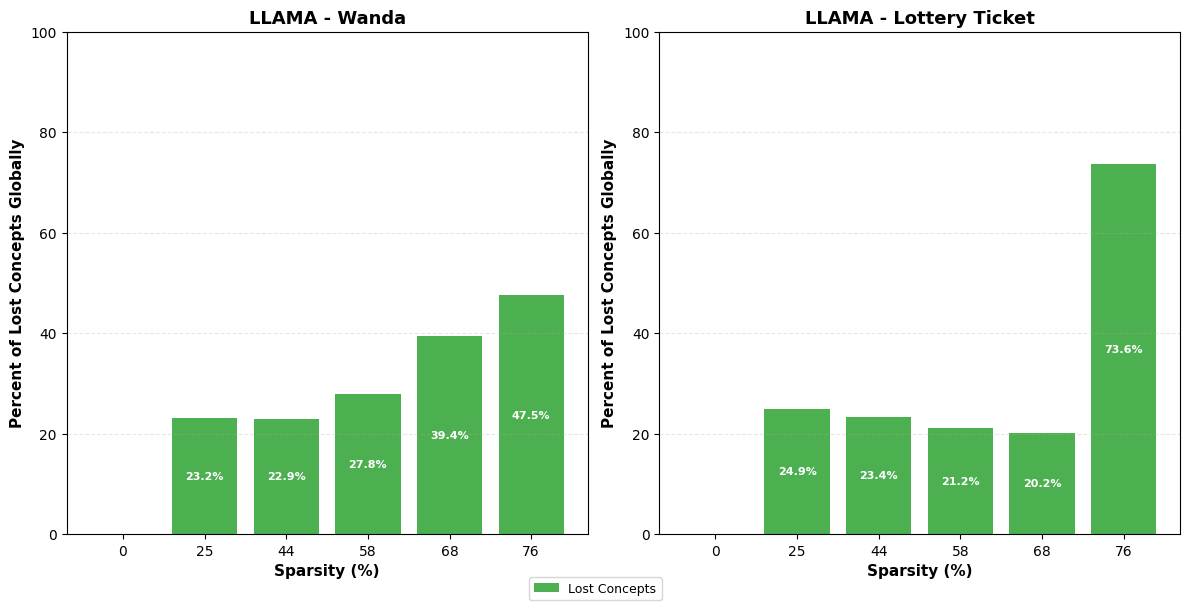


Analysis complete!


In [54]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os

pi = {0: 0.0, 1: 25.0, 2: 43.75, 3: 57.812, 4: 68.359, 5: 76.27}

def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts


def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings. Returns None if file not found."""
    if not Path(filepath).exists():
        return None
    try:
        df = pd.read_csv(filepath)
        unit_concepts = defaultdict(set)
        for _, row in df.iterrows():
            unit = row['unit']
            formula = row['best_name']
            concepts = get_indiv_concepts(formula)
            unit_concepts[unit].update(concepts)
        return unit_concepts
    except Exception as e:
        print(f"  Warning: Could not load {filepath}: {e}")
        return None


def build_concept_to_units_mapping(unit_concepts_dict):
    """Build a mapping from concepts to all units that explain them."""
    concept_to_units = defaultdict(set)
    for unit, concepts in unit_concepts_dict.items():
        for concept in concepts:
            concept_to_units[concept].add(unit)
    return dict(concept_to_units)


def get_runs(model, method, base_path_template):
    """
    Auto-discover run directories for a given model/method combination.
    Returns sorted list of run names.
    """
    exp_path = Path(base_path_template.format(model=model.upper(), method=method, run='').rstrip('/'))
    exp_path = exp_path.parent  # go up one level from where {run} would be

    if not exp_path.exists():
        return []

    runs = []
    for entry in exp_path.iterdir():
        if entry.is_dir():
            # Check that at least one %Pruned subdirectory exists inside Expls/
            expls_path = entry / 'Expls'
            if expls_path.exists() and any(
                re.match(r'[0-9.]+%Pruned', d.name) for d in expls_path.iterdir() if d.is_dir()
            ):
                runs.append(entry.name)

    return sorted(runs)


def get_pi(model, method, run, base_path_template):
    """
    Collect sparsity values from directory names inside Expls/.
    Returns sorted list of floats. Returns empty list if path not found.
    """
    base_path = Path(base_path_template.format(model=model.upper(), method=method, run=run))
    
    if not base_path.exists():
        return []

    sparsities = []
    for name in os.listdir(base_path):
        match = re.match(r"([0-9.]+)%Pruned", name)
        if match:
            sparsities.append(float(match.group(1)))

    return sorted(sparsities)


def build_pi_index(sparsity_list):
    """Convert a sorted list of sparsities into an index->sparsity dict."""
    return {i: s for i, s in enumerate(sparsity_list)}


def analyze_concept_migration(base_dir, pi_map, num_iterations=None, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """
    Analyze concept migration across pruning iterations for each cluster.
    All comparisons are made relative to iteration 0 (baseline).
    pi_map: dict mapping iteration index -> sparsity percentage
    """
    if num_iterations is None:
        num_iterations = len(pi_map) - 1

    results = {}
    
    for cluster in clusters:
        iteration_data = []
        

        for iteration in range(0, num_iterations + 1):
            if iteration not in pi_map:
                continue

            csv_path = Path(base_dir) / f"{pi_map[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
            #csv_path = Path("/workspace/CCE_NLI/LLAMA/exp/pretrained/Expls") / f"{cluster}IOUS1024N.csv" # {pi_map[0]}%Pruned"
            unit_concepts = load_csv_data(csv_path)
            
            

            if unit_concepts is None:
                continue  # skip missing file, don't count in avg

            concept_to_units = build_concept_to_units_mapping(unit_concepts)
            iteration_data.append({
                'iteration': iteration,
                'unit_concepts': unit_concepts,
                'concept_to_units': concept_to_units,
                'all_concepts': set(concept_to_units.keys())
            })

        if len(iteration_data) == 0:
            continue
        

        baseline = iteration_data[0]

        baseline_concepts = baseline['all_concepts']
        baseline_concept_to_units = baseline['concept_to_units']
        total_baseline = len(baseline_concepts)

        cluster_results = []
 
     
        for i in range(1, len(iteration_data)):
         
            try:
                curr_iter = iteration_data[i]
            
                curr_concepts = curr_iter['all_concepts']
                curr_concept_to_units = curr_iter['concept_to_units']

                new_concepts = curr_concepts - baseline_concepts
                disappeared_concepts = baseline_concepts - curr_concepts
                common_concepts = baseline_concepts & curr_concepts 
               

                stayed_same = set()
                moved_to_new = set()

                for concept in common_concepts:
                    baseline_units = baseline_concept_to_units[concept]
                    curr_units = curr_concept_to_units[concept]
                    if baseline_units & curr_units:
                        stayed_same.add(concept)
                    else:
                        moved_to_new.add(concept)

                total_curr = len(curr_concepts)
                if total_baseline > 0:
                    pct_new = 0
                    pct_stayed = (len(stayed_same) / total_baseline) * 100
                    pct_moved = (len(moved_to_new) / total_baseline) * 100
                else:
                    pct_new = pct_stayed = pct_moved = 0

                cluster_results.append({
                    'iteration': curr_iter['iteration'],
                    'pruning_pct': pi_map[curr_iter['iteration']],
                    'total_concepts_baseline': len(baseline_concepts),
                    'total_concepts_curr': total_curr,
                    'new_concepts': len(new_concepts),
                    'pct_new': pct_new,
                    'stayed_same': len(stayed_same),
                    'pct_stayed_same': pct_stayed,
                    'moved_to_new_unit': len(moved_to_new),
                    'pct_moved_to_new': pct_moved,
                    'disappeared_concepts': len(disappeared_concepts)
                })
            except Exception as e:
                print("exception ", e)
            
       

        results[cluster] = cluster_results

    return results


def analyze_cross_cluster_migration(base_dir, pi_map, num_iterations=None, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """Analyze concept migration across neurons and clusters."""
    if num_iterations is None:
        num_iterations = len(pi_map) - 1

    # Load baseline (iteration 0)
    baseline_cluster_data = {}
    baseline_concept_map = defaultdict(lambda: defaultdict(set))

    for cluster in clusters:
        if 0 not in pi_map:
            continue
        csv_path = Path(base_dir) /  f'{pi_map[0]}%Pruned' / f"{cluster}IOUS1024N.csv"
        print(csv_path)
        unit_concepts = load_csv_data(csv_path)
 
        if unit_concepts is None:
            continue  # skip missing baseline file

        baseline_cluster_data[cluster] = unit_concepts
        for unit, concepts in unit_concepts.items():
            for concept in concepts:
                baseline_concept_map[concept][cluster].add(unit)

    all_baseline_concepts = set(baseline_concept_map.keys())
    pretrained_concepts = load_csv_data(Path("/workspace/CCE_NLI/LLAMA/exp/pretrained/Expls/Cluster1IOUS1024N.csv"))
    
    
    all_pt_cp = set(build_concept_to_units_mapping(pretrained_concepts).keys())
    
    pretrained_concepts = load_csv_data(Path("/workspace/CCE_NLI/LLAMA/exp/pretrained/Expls/Cluster2IOUS1024N.csv"))
    all_pt_cp.update(set(build_concept_to_units_mapping(pretrained_concepts).keys()))


    pretrained_concepts = load_csv_data(Path("/workspace/CCE_NLI/LLAMA/exp/pretrained/Expls/Cluster3IOUS1024N.csv"))
    all_pt_cp.update(set(build_concept_to_units_mapping(pretrained_concepts).keys()))
    print("Num pt cp", len(all_pt_cp))

 
    migration_results = []

    for iteration in range(0, num_iterations + 1):
        if iteration not in pi_map:
            continue
            
        

        current_cluster_data = {}
        current_concept_map = defaultdict(lambda: defaultdict(set))

        for cluster in clusters:
            
            csv_path = Path(base_dir) / f"{pi_map[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
            print(f"Comparing {csv_path}")
            unit_concepts = load_csv_data(csv_path)
            if unit_concepts is None:
                continue  # skip missing file

            current_cluster_data[cluster] = unit_concepts
            for unit, concepts in unit_concepts.items():
                for concept in concepts:
                    current_concept_map[concept][cluster].add(unit)

        all_current_concepts = set(current_concept_map.keys())
        

        same_neuron_same_cluster = set()
        same_neuron_diff_cluster = set()
        diff_neuron_same_cluster = set()
        diff_neuron_diff_cluster = set()
        new_concepts = all_current_concepts - all_baseline_concepts
        disappeared_concepts = all_baseline_concepts - all_current_concepts
        common_concepts = all_baseline_concepts & all_current_concepts

        for concept in common_concepts:
            baseline_clusters = baseline_concept_map[concept]
            current_clusters = current_concept_map[concept]

            has_exact_match = False
            for cluster in baseline_clusters:
                if cluster in current_clusters:
                    if baseline_clusters[cluster] & current_clusters[cluster]:
                        has_exact_match = True
                        break

            if has_exact_match:
                same_neuron_same_cluster.add(concept)
                continue

            cross_cluster_migration = False
            for orig_cluster in baseline_clusters:
                baseline_units = baseline_clusters[orig_cluster]
                for other_cluster in current_clusters:
                    if other_cluster == orig_cluster:
                        continue
                    current_units = current_clusters[other_cluster]
                    for unit in baseline_units:
                        if unit in current_units and unit not in baseline_concept_map[concept].get(other_cluster, set()):
                            cross_cluster_migration = True
                            break
                    if cross_cluster_migration:
                        break
                if cross_cluster_migration:
                    break

            if cross_cluster_migration:
                same_neuron_diff_cluster.add(concept)
                continue

            has_same_cluster = any(cluster in current_clusters for cluster in baseline_clusters)
            if has_same_cluster:
                diff_neuron_same_cluster.add(concept)
            else:
                diff_neuron_diff_cluster.add(concept)

        total_baseline = len(all_baseline_concepts)
        total_current = len(all_current_concepts)
        print(f"concepts common to sparse, dense, pretrained {len(all_baseline_concepts&all_current_concepts&all_pt_cp)}")
        print(f"concepts common to dense, pretrained {len(all_baseline_concepts & all_pt_cp)}")
      
        print(f"concepts between sparse and (dense that are not in pretrained) = {len(all_current_concepts & (all_baseline_concepts - all_pt_cp))}")
        print(f"concets in dense not in pretrained {len(all_baseline_concepts - all_pt_cp)}")
        
        print(f"concepts between sparse and (pretrained that are not in dense) = {len(all_current_concepts & (all_pt_cp - all_baseline_concepts))}")
        print(f"num SPARSE concepts = {len(all_current_concepts)}")
        
        

        result = {
            'iteration': iteration,
            'pruning_pct': pi_map[iteration],
            'total_baseline_concepts': total_baseline,
            'total_current_concepts': total_current,
            'same_neuron_same_cluster': len(same_neuron_same_cluster),
            'same_neuron_diff_cluster': len(same_neuron_diff_cluster),
            'diff_neuron_same_cluster': len(diff_neuron_same_cluster),
            'diff_neuron_diff_cluster': len(diff_neuron_diff_cluster),
            'new_concepts': len(new_concepts),
            'disappeared_concepts': len(disappeared_concepts),
        }

        if total_baseline > 0:
            result['pct_same_neuron_same_cluster'] = (len(same_neuron_same_cluster) / total_baseline) * 100
            result['pct_same_neuron_diff_cluster'] = (len(same_neuron_diff_cluster) / total_baseline) * 100
            result['pct_diff_neuron_same_cluster'] = (len(diff_neuron_same_cluster) / total_baseline) * 100
            result['pct_diff_neuron_diff_cluster'] = (len(diff_neuron_diff_cluster) / total_baseline) * 100
            result['lost_concepts'] = (result['disappeared_concepts'] / total_baseline) * 100
        else:
            result['pct_same_neuron_same_cluster'] = 0
            result['pct_same_neuron_diff_cluster'] = 0
            result['pct_diff_neuron_same_cluster'] = 0
            result['pct_diff_neuron_diff_cluster'] = 0
            result['lost_concepts'] = 0

        migration_results.append(result)

    return migration_results


def analyze_all_models_methods_multiple_runs(base_path_template, models, methods, runs=None):
    """
    Analyze all model-method combinations across multiple runs.
    If runs=None, auto-discovers runs from the filesystem.
    Missing files/directories are skipped and NOT counted in the average.
    """
    all_runs_results = {
        'per_cluster': defaultdict(lambda: defaultdict(list)),
        'cross_cluster': defaultdict(lambda: defaultdict(list))
    }

    for model in models:
        for method in methods:
            # Auto-discover runs if not provided
            effective_runs = runs
            if effective_runs is None:
                effective_runs = get_runs(model, method, base_path_template)
                if not effective_runs:
                    print(f"Warning: No runs found for {model} - {method}")
                    continue
                if model=='LLAMA' and method=='lottery_ticket':
                    effective_runs.remove("Run0.25_6")
                print(f"Auto-discovered runs for {model} - {method}: {effective_runs}")

            print(f"\n{'='*80}")
            print(f"Processing: {model} - {method} ({len(effective_runs)} runs)")
            print(f"{'='*80}")

            for run in effective_runs:
                base_dir = base_path_template.format(model=model.upper(), method=method, run=run)

                if not Path(base_dir).exists():
                    print(f"  Skipping {run}: directory not found")
                    continue

                try:
                    pi_list = get_pi(model, method, run, base_path_template)
                    if not pi_list:
                        print(f"  Skipping {run}: no pruned directories found")
                        continue
                    pi_map = build_pi_index(pi_list)
                  
                    per_cluster = analyze_concept_migration(base_dir, pi_map)
             
                    cross_cluster = analyze_cross_cluster_migration(base_dir, pi_map)
                    

                    # Only store if we got meaningful results
                    if per_cluster:
                        all_runs_results['per_cluster'][model][method].append(per_cluster)
                    if cross_cluster:
                        all_runs_results['cross_cluster'][model][method].append(cross_cluster)

                    print(f"  ✓ {run}")
                except Exception as e:
                    print(f"  ✗ {run}: {e}")

    print(f"\n{'='*80}")
    print("AVERAGING RESULTS ACROSS RUNS")
    print("(only successfully loaded runs are counted)")
    print(f"{'='*80}")

    averaged_results = average_across_runs(all_runs_results, models, methods)
    return averaged_results


def average_across_runs(all_runs_results, models, methods):
    """
    Average results across multiple runs.
    Only runs that were actually loaded are included in the average.
    """
    averaged = {
        'per_cluster': {},
        'cross_cluster': {}
    }

    # Average per-cluster results
    for model in models:
        averaged['per_cluster'][model] = {}

        for method in methods:
            runs_data = all_runs_results['per_cluster'][model][method]

            if not runs_data:
                averaged['per_cluster'][model][method] = None
                continue

            n_runs = len(runs_data)
            print(f"  Per-cluster average for {model} - {method}: {n_runs} run(s)")
            averaged_clusters = {}

            if runs_data[0]:
                clusters = runs_data[0].keys()

                for cluster in clusters:
                    cluster_data_across_runs = [
                        run_data[cluster]
                        for run_data in runs_data
                        if cluster in run_data and run_data[cluster]
                    ]

                    if not cluster_data_across_runs:
                        continue

                    num_iterations = len(cluster_data_across_runs[0])
                    averaged_iterations = []

                    for iter_idx in range(num_iterations):
                        iter_metrics = defaultdict(list)

                        for run_data in cluster_data_across_runs:
                            if iter_idx < len(run_data):
                                for key, value in run_data[iter_idx].items():
                                    if isinstance(value, (int, float)):
                                        iter_metrics[key].append(value)

                        averaged_iter = {key: np.mean(values) for key, values in iter_metrics.items()}

                        # Preserve non-numeric fields from first run
                        if cluster_data_across_runs[0] and iter_idx < len(cluster_data_across_runs[0]):
                            averaged_iter['iteration'] = cluster_data_across_runs[0][iter_idx]['iteration']
                            averaged_iter['pruning_pct'] = cluster_data_across_runs[0][iter_idx]['pruning_pct']

                        averaged_iterations.append(averaged_iter)

                    averaged_clusters[cluster] = averaged_iterations

            averaged['per_cluster'][model][method] = averaged_clusters

    # Average cross-cluster results
    for model in models:
        averaged['cross_cluster'][model] = {}

        for method in methods:
            runs_data = all_runs_results['cross_cluster'][model][method]

            if not runs_data:
                averaged['cross_cluster'][model][method] = None
                continue

            n_runs = len(runs_data)
            print(f"  Cross-cluster average for {model} - {method}: {n_runs} run(s)")

            num_iterations = len(runs_data[0]) if runs_data[0] else 0
            averaged_iterations = []

            for iter_idx in range(num_iterations):
                iter_metrics = defaultdict(list)

                for run_data in runs_data:
                    if iter_idx < len(run_data):
                        for key, value in run_data[iter_idx].items():
                            if isinstance(value, (int, float)):
                                iter_metrics[key].append(value)

                averaged_iter = {key: np.mean(values) for key, values in iter_metrics.items()}
                averaged_iter.update({f'{key}_std': np.std(values) for key, values in iter_metrics.items()})

                if runs_data[0] and iter_idx < len(runs_data[0]):
                    averaged_iter['iteration'] = runs_data[0][iter_idx]['iteration']
                    averaged_iter['pruning_pct'] = runs_data[0][iter_idx]['pruning_pct']

                averaged_iterations.append(averaged_iter)

            averaged['cross_cluster'][model][method] = averaged_iterations

    return averaged


def print_concept_summary(cross_cluster_results, models, methods):
    for model in models:
        for method in methods:
            migration_results = cross_cluster_results.get(model, {}).get(method)
            if migration_results is None:
                continue

            print(f"\n{'='*100}")
            print(f"CONCEPT LOSS/PRESERVATION SUMMARY: {model.upper()} - {method.replace('_', ' ').title()}")
            print(f"{'='*100}\n")

            if len(migration_results) > 0:
                total_baseline = migration_results[0]['total_baseline_concepts']
                print(f"Baseline (0% Pruned): {total_baseline:.0f} total concepts (averaged across runs)\n")

                print(f"{'Iter':<6} {'Sparsity':<10} {'Preserved':<25} {'Lost':<25} {'Preserved %':<20} {'Lost %':<15}")
                print(f"{'-'*6} {'-'*10} {'-'*25} {'-'*25} {'-'*20} {'-'*15}")

                for result in migration_results:
                    iteration = int(result['iteration'])
                    sparsity = result['pruning_pct']

                    preserved = (result['same_neuron_same_cluster'] +
                                 result['same_neuron_diff_cluster'] +
                                 result['diff_neuron_same_cluster'] +
                                 result['diff_neuron_diff_cluster'])
                    lost = result['disappeared_concepts']

                    preserved_pct = (preserved / total_baseline) * 100
                    lost_pct = (lost / total_baseline) * 100

                    preserved_std = (result.get('same_neuron_same_cluster_std', 0) +
                                     result.get('same_neuron_diff_cluster_std', 0) +
                                     result.get('diff_neuron_same_cluster_std', 0) +
                                     result.get('diff_neuron_diff_cluster_std', 0))
                    lost_std = result.get('disappeared_concepts_std', 0)

                    preserved_str = f"{preserved:.1f}/{total_baseline:.0f} (±{preserved_std:.1f})"
                    lost_str = f"{lost:.1f}/{total_baseline:.0f} (±{lost_std:.1f})"

                    print(f"{iteration:<6} {sparsity:<10.2f} {preserved_str:<25} {lost_str:<25} "
                          f"{preserved_pct:<20.2f} {lost_pct:<15.2f}")

                print(f"\n{'='*100}\n")


def print_detailed_concept_summary(cross_cluster_results, models, methods):
    for model in models:
        for method in methods:
            migration_results = cross_cluster_results.get(model, {}).get(method)
            if migration_results is None:
                continue

            print(f"\n{'='*100}")
            print(f"DETAILED CONCEPT BREAKDOWN: {model.upper()} - {method.replace('_', ' ').title()}")
            print(f"{'='*100}\n")

            if len(migration_results) > 0:
                total_baseline = migration_results[0]['total_baseline_concepts']
                print(f"Baseline: {total_baseline:.0f} concepts (averaged across runs)\n")

                for result in migration_results:
                    iteration = int(result['iteration'])
                    sparsity = result['pruning_pct']

                    same_n_same_c = result['same_neuron_same_cluster']
                    same_n_diff_c = result['same_neuron_diff_cluster']
                    diff_n_same_c = result['diff_neuron_same_cluster']
                    diff_n_diff_c = result['diff_neuron_diff_cluster']
                    lost = result['disappeared_concepts']

                    same_n_same_c_std = result.get('same_neuron_same_cluster_std', 0)
                    same_n_diff_c_std = result.get('same_neuron_diff_cluster_std', 0)
                    diff_n_same_c_std = result.get('diff_neuron_same_cluster_std', 0)
                    diff_n_diff_c_std = result.get('diff_neuron_diff_cluster_std', 0)
                    lost_std = result.get('disappeared_concepts_std', 0)

                    total_preserved = same_n_same_c + same_n_diff_c + diff_n_same_c + diff_n_diff_c
                    total_preserved_std = same_n_same_c_std + same_n_diff_c_std + diff_n_same_c_std + diff_n_diff_c_std

                    print(f"Iteration {iteration} ({sparsity:.2f}% Sparse)")
                    print(f"{'-'*100}")
                    print(f"  PRESERVED: {total_preserved:.1f}/{total_baseline:.0f} (±{total_preserved_std:.1f}) "
                          f"[{(total_preserved/total_baseline)*100:.2f}%]")
                    print(f"    ├─ Same Neuron, Same Cluster:    {same_n_same_c:>7.1f} (±{same_n_same_c_std:>5.1f})  "
                          f"[{(same_n_same_c/total_baseline)*100:>6.2f}%]")
                    print(f"    ├─ Same Neuron, Diff Cluster:    {same_n_diff_c:>7.1f} (±{same_n_diff_c_std:>5.1f})  "
                          f"[{(same_n_diff_c/total_baseline)*100:>6.2f}%]")
                    print(f"    ├─ Diff Neuron, Same Cluster:    {diff_n_same_c:>7.1f} (±{diff_n_same_c_std:>5.1f})  "
                          f"[{(diff_n_same_c/total_baseline)*100:>6.2f}%]")
                    print(f"    └─ Diff Neuron, Diff Cluster:    {diff_n_diff_c:>7.1f} (±{diff_n_diff_c_std:>5.1f})  "
                          f"[{(diff_n_diff_c/total_baseline)*100:>6.2f}%]")
                    print(f"  LOST:      {lost:.1f}/{total_baseline:.0f} (±{lost_std:.1f}) "
                          f"[{(lost/total_baseline)*100:.2f}%]")
                    print()


def print_concept_summary_per(per_cluster_results, models, methods):
    for model in models:
        for method in methods:
            migration_results = per_cluster_results.get(model, {}).get(method)

            print(f"\n{'='*80}")
            print(f"CONCEPT LOSS/PRESERVATION SUMMARY: {model.upper()} - {method.replace('_', ' ').title()}")
            print(f"{'='*80}\n")

            if migration_results is None:
                print("  No results available.")
                continue

            for c in migration_results:
                print(c)
                if migration_results[c] is None:
                    continue

                if len(migration_results[c]) > 0:
                    total_baseline = migration_results[c][0]['total_concepts_baseline']
                    print(f"Baseline (0% Pruned): {total_baseline} total concepts\n")

                    print(f"{'Iteration':<10} {'Sparsity':<10} {'Preserved':<20} {'Lost':<20} {'Preserved %':<15} {'Lost %':<10}")
                    print(f"{'-'*10} {'-'*10} {'-'*20} {'-'*20} {'-'*15} {'-'*10}")

                    for result in migration_results[c]:
                        iteration = result['iteration']
                        sparsity = result['pruning_pct']
                        preserved = result['stayed_same'] + result['moved_to_new_unit']
                        lost = result['disappeared_concepts']
                        preserved_pct = (preserved / total_baseline) * 100
                        lost_pct = (lost / total_baseline) * 100
                        preserved_str = f"{preserved}/{total_baseline}"
                        lost_str = f"{lost}/{total_baseline}"
                        print(f"{iteration:<10} {sparsity:<10.2f} {preserved_str:<20} {lost_str:<20} "
                              f"{preserved_pct:<15.2f} {lost_pct:<10.2f}")

                    print(f"\n{'='*80}\n")


def create_summary_dataframe(cross_cluster_results, models, methods):
    summary_data = []

    for model in models:
        for method in methods:
            migration_results = cross_cluster_results.get(model, {}).get(method)
            if migration_results is None:
                continue

            if len(migration_results) > 0:
                total_baseline = migration_results[0]['total_baseline_concepts']

                for result in migration_results:
                    preserved = (result['same_neuron_same_cluster'] +
                                 result['same_neuron_diff_cluster'] +
                                 result['diff_neuron_same_cluster'] +
                                 result['diff_neuron_diff_cluster'])
                    lost = result['disappeared_concepts']

                    summary_data.append({
                        'Model': model,
                        'Method': method,
                        'Iteration': int(result['iteration']),
                        'Sparsity_%': result['pruning_pct'],
                        'Total_Baseline': total_baseline,
                        'Preserved': preserved,
                        'Preserved_Std': (result.get('same_neuron_same_cluster_std', 0) +
                                          result.get('same_neuron_diff_cluster_std', 0) +
                                          result.get('diff_neuron_same_cluster_std', 0) +
                                          result.get('diff_neuron_diff_cluster_std', 0)),
                        'Lost': lost,
                        'Lost_Std': result.get('disappeared_concepts_std', 0),
                        'Preserved_%': (preserved / total_baseline) * 100,
                        'Lost_%': (lost / total_baseline) * 100,
                        'Same_Neuron_Same_Cluster': result['same_neuron_same_cluster'],
                        'Same_Neuron_Diff_Cluster': result['same_neuron_diff_cluster'],
                        'Diff_Neuron_Same_Cluster': result['diff_neuron_same_cluster'],
                        'Diff_Neuron_Diff_Cluster': result['diff_neuron_diff_cluster']
                    })

    return pd.DataFrame(summary_data)


def plot_multi_model_concept_migration(per_cluster_results, models, methods,
                                       save_path='multi_model_concept_migration.png',
                                       clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    for cluster in clusters:
        valid_combos = [
            (model, method)
            for model in models for method in methods
            if per_cluster_results.get(model, {}).get(method) is not None
            and cluster in per_cluster_results[model][method]
        ]

        if not valid_combos:
            print(f"No valid per-cluster results to plot for {cluster}!")
            continue

        num_combos = len(valid_combos)
        ncols = min(3, num_combos)
        nrows = (num_combos + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 6 * nrows))
        if num_combos == 1:
            axes = np.array([axes])
        axes = axes.flatten() if num_combos > 1 else axes

        for idx, (model, method) in enumerate(valid_combos):
            ax = axes[idx]
            cluster_results = per_cluster_results[model][method][cluster]

            iterations = [r['iteration'] for r in cluster_results]
            pct_new = [r['pct_new'] for r in cluster_results]
            pct_stayed = [r['pct_stayed_same'] for r in cluster_results]
            pct_moved = [r['pct_moved_to_new'] for r in cluster_results]

            x = np.arange(len(iterations))
            p1 = ax.bar(x, pct_stayed, label='Stayed Same Unit', color='#2196F3')
            p2 = ax.bar(x, pct_moved, bottom=pct_stayed, label='Moved to New Unit', color='#FF9800')
            p3 = ax.bar(x, pct_new, bottom=np.array(pct_stayed) + np.array(pct_moved),
                        label='New Concepts', color='#4CAF50')

            for i in range(len(iterations)):
                if pct_stayed[i] > 5:
                    ax.text(i, pct_stayed[i] / 2, f'{pct_stayed[i]:.1f}%',
                            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
                if pct_moved[i] > 5:
                    ax.text(i, pct_stayed[i] + pct_moved[i] / 2, f'{pct_moved[i]:.1f}%',
                            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
                if pct_new[i] > 5:
                    ax.text(i, pct_stayed[i] + pct_moved[i] + pct_new[i] / 2, f'{pct_new[i]:.1f}%',
                            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

            ax.set_xlabel('Sparsity (%)', fontsize=13, fontweight='bold')
            ax.set_ylabel('Percent of Concepts', fontsize=13, fontweight='bold')
            ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}',
                         fontsize=15, fontweight='bold', pad=15)
            ax.set_xticks(x)
            ax.set_xticklabels([f'{r["pruning_pct"]:.0f}' for r in cluster_results], fontsize=11)
            ax.set_yticks([0, 25, 50, 75, 100])
            ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=11)
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            ax.set_ylim(0, 100)

        for idx in range(num_combos, len(axes)):
            axes[idx].axis('off')

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12,
                   bbox_to_anchor=(0.5, -0.01), frameon=True)

        plt.tight_layout()
        plt.subplots_adjust(bottom=0.06)

        cluster_save_path = save_path.replace('.png', f'_{cluster}.png')
        plt.savefig(cluster_save_path, dpi=300, bbox_inches='tight')
        print(f"Concept migration plot for {cluster} saved to '{cluster_save_path}'")
        plt.show()


def plot_lost_concepts(per_iteration_results, models, methods,
                       save_path='lost_concepts.png'):
    valid_combos = [
        (model, method)
        for model in models for method in methods
        if per_iteration_results.get(model, {}).get(method) is not None
    ]

    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return

    num_combos = len(valid_combos)
    ncols = min(3, num_combos)
    nrows = (num_combos + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    if num_combos == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_combos > 1 else axes

    for idx, (model, method) in enumerate(valid_combos):
        ax = axes[idx]
        migration_results = per_iteration_results[model][method]

        lost_concepts = [r['lost_concepts'] for r in migration_results if 'lost_concepts' in r]

        x = np.arange(len(migration_results))
        p1 = ax.bar(x, lost_concepts, label='Lost Concepts', color='#4CAF50')

        for bar in p1:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width() / 2.,
                        height / 2, f'{height:.1f}%',
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')

        ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percent of Lost Concepts Globally', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{r["pruning_pct"]:.0f}' for r in migration_results])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 100)

    for idx in range(num_combos, len(axes)):
        axes[idx].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Lost concepts plot saved to '{save_path}'")
    plt.show()


def plot_multi_model_cross_cluster_migration(cross_cluster_results, models, methods,
                                             save_path='multi_model_cross_cluster_migration.png'):
    valid_combos = [
        (model, method)
        for model in models for method in methods
        if cross_cluster_results.get(model, {}).get(method) is not None
    ]

    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return

    num_combos = len(valid_combos)
    ncols = min(3, num_combos)
    nrows = (num_combos + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    if num_combos == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_combos > 1 else axes

    colors = {
        'same_neuron_same_cluster': '#4CAF50',
        'diff_neuron_same_cluster': '#FF9800',
        'same_neuron_diff_cluster': '#2196F3',
        'diff_neuron_diff_cluster': '#F44336',
        'lost_concepts': '#9C27B0'
    }

    for idx, (model, method) in enumerate(valid_combos):
        ax = axes[idx]
        migration_results = cross_cluster_results[model][method]

        same_n_same_c = [r['pct_same_neuron_same_cluster'] for r in migration_results]
        same_n_diff_c = [r['pct_same_neuron_diff_cluster'] for r in migration_results]
        diff_n_same_c = [r['pct_diff_neuron_same_cluster'] for r in migration_results]
        diff_n_diff_c = [r['pct_diff_neuron_diff_cluster'] for r in migration_results]
        lost_concepts = [r['lost_concepts'] for r in migration_results]

        x = np.arange(len(migration_results))

        p1 = ax.bar(x, same_n_same_c, label='Same Neuron, Same Cluster', color=colors['same_neuron_same_cluster'])
        p2 = ax.bar(x, diff_n_same_c, bottom=same_n_same_c, label='Diff Neuron, Same Cluster', color=colors['diff_neuron_same_cluster'])
        p3 = ax.bar(x, same_n_diff_c, bottom=np.array(same_n_same_c) + np.array(diff_n_same_c),
                    label='Same Neuron, Diff Cluster', color=colors['same_neuron_diff_cluster'])
        p4 = ax.bar(x, diff_n_diff_c, bottom=np.array(same_n_same_c) + np.array(diff_n_same_c) + np.array(same_n_diff_c),
                    label='Diff Neuron, Diff Cluster', color=colors['diff_neuron_diff_cluster'])
        p5 = ax.bar(x, lost_concepts,
                    bottom=np.array(same_n_same_c) + np.array(same_n_diff_c) + np.array(diff_n_same_c) + np.array(diff_n_diff_c),
                    label='Lost Concepts', color=colors['lost_concepts'])

        bar_containers = [p1, p2, p3, p4, p5]
        bottoms = [
            np.zeros(len(x)),
            np.array(same_n_same_c),
            np.array(same_n_same_c) + np.array(diff_n_same_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c) + np.array(diff_n_same_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c) + np.array(diff_n_same_c) + np.array(diff_n_diff_c)
        ]

        for bars, bottom in zip(bar_containers, bottoms):
            for bar, base in zip(bars, bottom):
                height = bar.get_height()
                if height > 3:
                    ax.text(bar.get_x() + bar.get_width() / 2.,
                            base + height / 2, f'{height:.1f}%',
                            ha='center', va='center', fontsize=8, fontweight='bold', color='white')

        ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percent of Concepts', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{r["pruning_pct"]:.0f}' for r in migration_results])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 100)

    for idx in range(num_combos, len(axes)):
        axes[idx].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Cross-cluster migration plot saved to '{save_path}'")
    plt.show()


if __name__ == "__main__":
    models = ['LLAMA'] #, 'BERT', 'BOWMAN']
    methods = ['wanda', 'lottery_ticket', 'CoFi']
    base_path_template = "/workspace/CCE_NLI/{model}/exp/{method}/{run}/Expls/"

    # Pass runs=None to auto-discover, or pass a list to use specific runs:
    # runs = ['Run0.25_5', 'Run0.25_6', 'Run0.25_7']
    runs = None  # auto-discover

    print("=" * 80)
    print("MULTI-RUN MIGRATION ANALYSIS")
    print("Runs: auto-discovered from filesystem (missing files skipped)")
    print("=" * 80)

    averaged_results = analyze_all_models_methods_multiple_runs(
        base_path_template=base_path_template,
        models=models,
        methods=methods,
        runs=runs
    )

    print("\n" + "=" * 80)
    print("AVERAGED CONCEPT LOSS/PRESERVATION SUMMARIES GLOBAL")
    print("=" * 80)
    print_concept_summary(averaged_results['cross_cluster'], models, methods)

    print("\n" + "=" * 80)
    print("AVERAGED CONCEPT LOSS/PRESERVATION SUMMARIES LOCAL")
    print("=" * 80)
    print_concept_summary_per(averaged_results['per_cluster'], models, methods)

    print("\n" + "=" * 80)
    print("AVERAGED DETAILED CONCEPT BREAKDOWNS")
    print("=" * 80)
    print_detailed_concept_summary(averaged_results['cross_cluster'], models, methods)

    summary_df = create_summary_dataframe(averaged_results['cross_cluster'], models, methods)
    summary_df.to_csv('averaged_concept_summary.csv', index=False)
    print("\nAveraged summary saved to 'averaged_concept_summary.csv'")

    print("\n" + "=" * 80)
    print("GENERATING PER-CLUSTER CONCEPT MIGRATION PLOTS (AVERAGED)")
    print("=" * 80)
    plot_multi_model_concept_migration(
        per_cluster_results=averaged_results['per_cluster'],
        models=models,
        methods=methods,
        save_path='averaged_multi_model_concept_migration.png'
    )

    print("\n" + "=" * 80)
    print("GENERATING CROSS-CLUSTER MIGRATION PLOTS (AVERAGED)")
    print("=" * 80)
    plot_multi_model_cross_cluster_migration(
        cross_cluster_results=averaged_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='averaged_multi_model_cross_cluster_migration.png'
    )

    plot_lost_concepts(
        per_iteration_results=averaged_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='averaged_lost_concepts.png'
    )

    print("\n" + "=" * 80)
    print("Analysis complete!")
    print("=" * 80)

ALGINMENT W DEFAULT

MULTI-RUN MIGRATION ANALYSIS
Runs: auto-discovered from filesystem (missing files skipped)
Auto-discovered runs for LLAMA - wanda: ['Run0.25_5']

Processing: LLAMA - wanda (1 runs)
exception  6
exception  6
exception  6
sparse&dense&pt =  288
dense&pt =  0.7093596059113301
0.0 || % of dense concepts that are sae as default = 70.93596059113301
0.0 || % of sparse concepts that are sae as default = 70.93596059113301
0.0 || % of sparse concepts that are sae as dense = 100.0
0.0 || % of sparse concepts that are in dense&pretrained = 70.93596059113301
sparse&dense&pt =  247
dense&pt =  0.7093596059113301
25.0 || % of dense concepts that are sae as default = 70.93596059113301
25.0 || % of sparse concepts that are sae as default = 71.94805194805195
25.0 || % of sparse concepts that are sae as dense = 81.03896103896103
25.0 || % of sparse concepts that are in dense&pretrained = 64.15584415584415
sparse&dense&pt =  245
dense&pt =  0.7093596059113301
43.75 || % of dense concepts that are sae as d

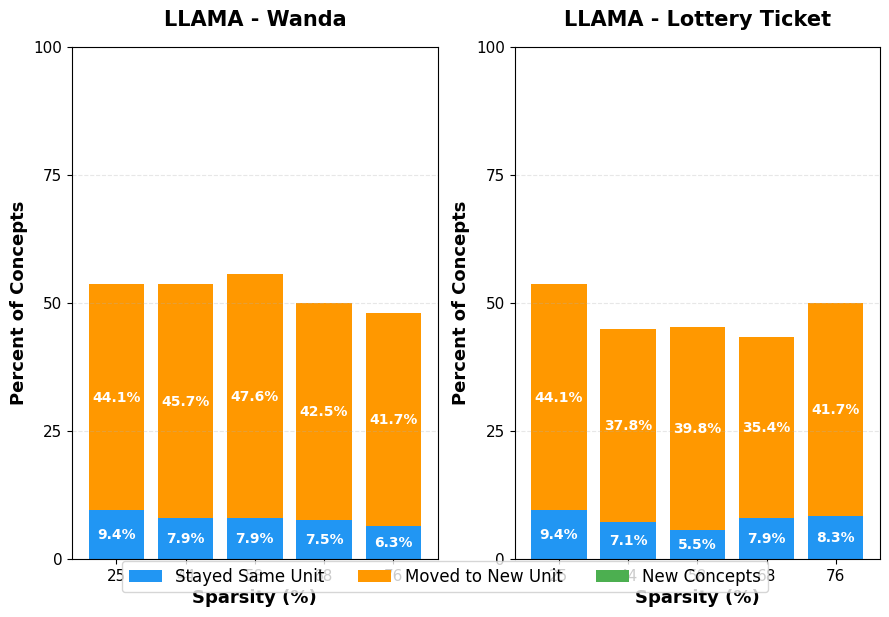

Concept migration plot for Cluster2 saved to 'averaged_multi_model_concept_migration_Cluster2.png'


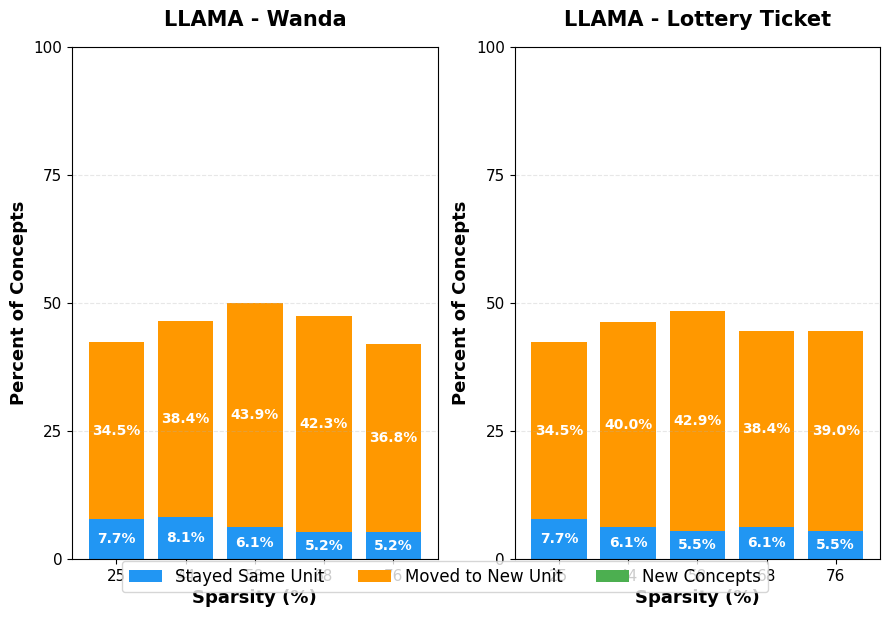

Concept migration plot for Cluster3 saved to 'averaged_multi_model_concept_migration_Cluster3.png'


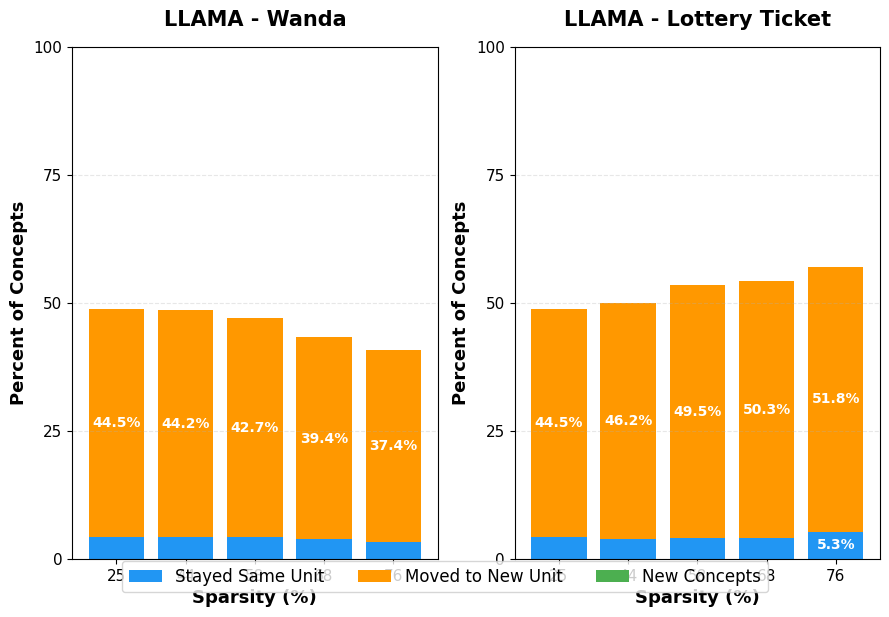


GENERATING CROSS-CLUSTER MIGRATION PLOTS (AVERAGED)
Cross-cluster migration plot saved to 'averaged_multi_model_cross_cluster_migration.png'


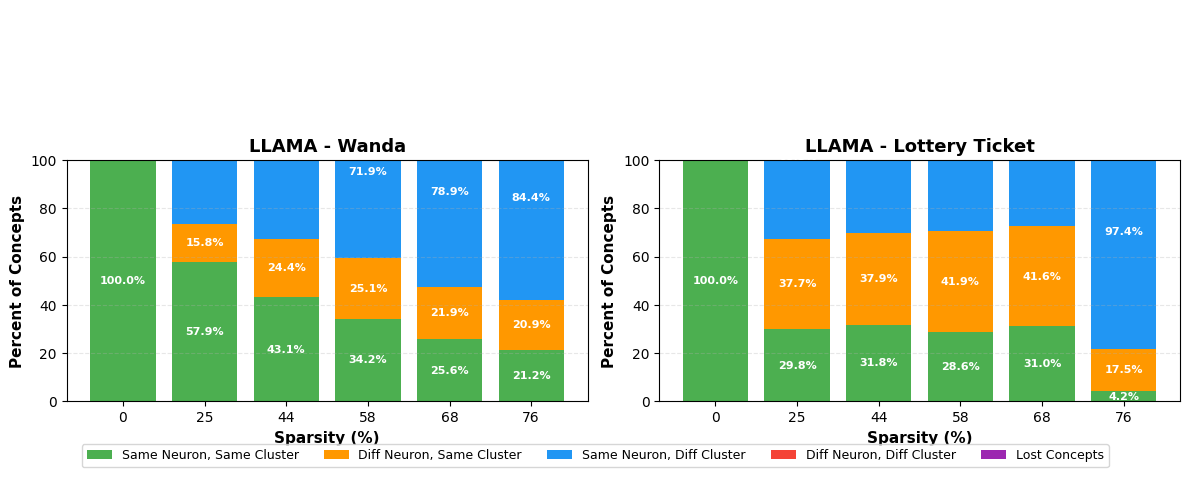

Lost concepts plot saved to 'averaged_lost_concepts.png'


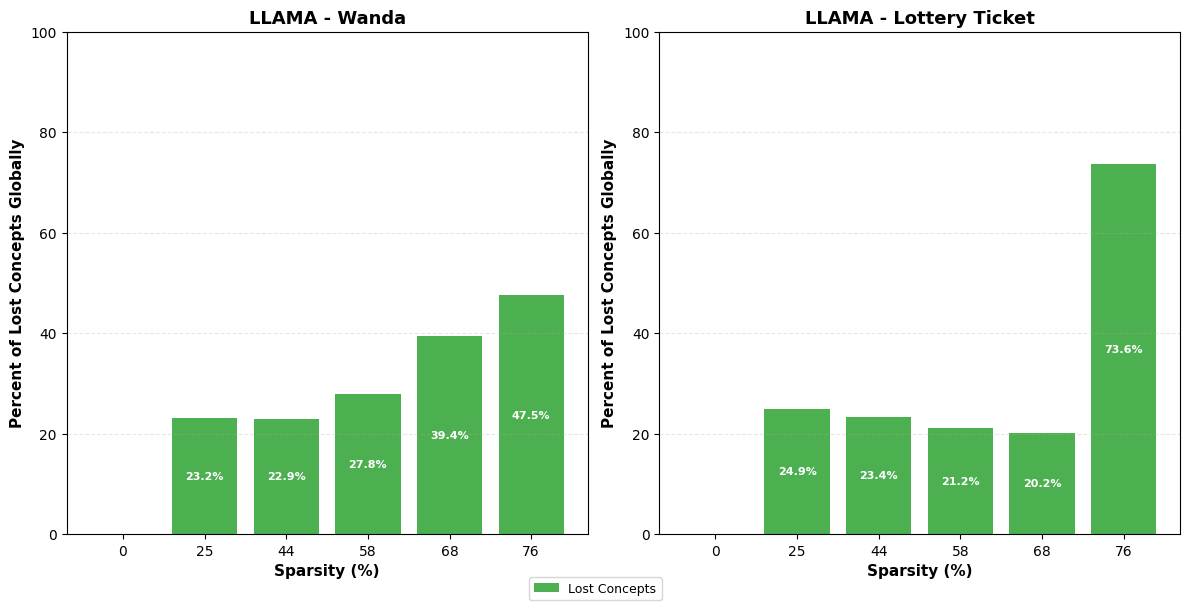


Analysis complete!


In [70]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os

pi = {0: 0.0, 1: 25.0, 2: 43.75, 3: 57.812, 4: 68.359, 5: 76.27}

def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts


def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings. Returns None if file not found."""
 
    if not Path(filepath).exists():
        return None
    try:
        df = pd.read_csv(filepath)
        unit_concepts = defaultdict(set)
        for _, row in df.iterrows():
            unit = row['unit']
            formula = row['best_name']
            concepts = get_indiv_concepts(formula)
            unit_concepts[unit].update(concepts)
        return unit_concepts
    except Exception as e:
        print(f"  Warning: Could not load {filepath}: {e}")
        return None


def build_concept_to_units_mapping(unit_concepts_dict):
    """Build a mapping from concepts to all units that explain them."""
    concept_to_units = defaultdict(set)
    for unit, concepts in unit_concepts_dict.items():
        for concept in concepts:
            concept_to_units[concept].add(unit)
    return dict(concept_to_units)


def get_runs(model, method, base_path_template):
    """
    Auto-discover run directories for a given model/method combination.
    Returns sorted list of run names.
    """
    exp_path = Path(base_path_template.format(model=model.upper(), method=method, run='').rstrip('/'))
    exp_path = exp_path.parent  # go up one level from where {run} would be

    if not exp_path.exists():
        return []

    runs = []
    for entry in exp_path.iterdir():
        if entry.is_dir():
            # Check that at least one %Pruned subdirectory exists inside Expls/
            expls_path = entry / 'Expls'
            if expls_path.exists() and any(
                re.match(r'[0-9.]+%Pruned', d.name) for d in expls_path.iterdir() if d.is_dir()
            ):
                runs.append(entry.name)

    return sorted(runs)


def get_pi(model, method, run, base_path_template):
    """
    Collect sparsity values from directory names inside Expls/.
    Returns sorted list of floats. Returns empty list if path not found.
    """
    base_path = Path(base_path_template.format(model=model.upper(), method=method, run=run))
    
    if not base_path.exists():
        return []

    sparsities = []
    for name in os.listdir(base_path):
        match = re.match(r"([0-9.]+)%Pruned", name)
        if match:
            sparsities.append(float(match.group(1)))

    return sorted(sparsities)


def build_pi_index(sparsity_list):
    """Convert a sorted list of sparsities into an index->sparsity dict."""
    return {i: s for i, s in enumerate(sparsity_list)}


def analyze_concept_migration(base_dir, pi_map, num_iterations=None, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """
    Analyze concept migration across pruning iterations for each cluster.
    All comparisons are made relative to iteration 0 (baseline).
    pi_map: dict mapping iteration index -> sparsity percentage
    """
    if num_iterations is None:
        num_iterations = len(pi_map) - 1

    results = {}
    
    for cluster in clusters:
        iteration_data = []
        csv_path = Path("/workspace/CCE_NLI/LLAMA/exp/pretrained/Expls") / f"{cluster}IOUS1024N.csv" # {pi_map[0]}%Pruned"
        unit_concepts = load_csv_data(csv_path)

        if unit_concepts is None:
            continue  # skip missing file, don't count in avg

        concept_to_units = build_concept_to_units_mapping(unit_concepts)
        iteration_data.append({
            'iteration': 0,
            'unit_concepts': unit_concepts,
            'concept_to_units': concept_to_units,
            'all_concepts': set(concept_to_units.keys())
        })
        

        for iteration in range(0, num_iterations + 1):
            if iteration not in pi_map:
                continue

            csv_path = Path(base_dir) / f"{pi_map[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
            #csv_path = Path("/workspace/CCE_NLI/LLAMA/exp/pretrained/Expls") / f"{cluster}IOUS1024N.csv" # {pi_map[0]}%Pruned"
            unit_concepts = load_csv_data(csv_path)

            if unit_concepts is None:
                continue  # skip missing file, don't count in avg

            concept_to_units = build_concept_to_units_mapping(unit_concepts)
            iteration_data.append({
                'iteration': iteration+1,
                'unit_concepts': unit_concepts,
                'concept_to_units': concept_to_units,
                'all_concepts': set(concept_to_units.keys())
            })

        if len(iteration_data) == 0:
            continue
        

        baseline = iteration_data[0]

        baseline_concepts = baseline['all_concepts']
        baseline_concept_to_units = baseline['concept_to_units']
        total_baseline = len(baseline_concepts)

        cluster_results = []
 
     
        for i in range(1, len(iteration_data)):
         
            try:
                curr_iter = iteration_data[i]
            
                curr_concepts = curr_iter['all_concepts']
                curr_concept_to_units = curr_iter['concept_to_units']

                new_concepts = curr_concepts - baseline_concepts
                disappeared_concepts = baseline_concepts - curr_concepts
                common_concepts = baseline_concepts & curr_concepts
                

                stayed_same = set()
                moved_to_new = set()

                for concept in common_concepts:
                    baseline_units = baseline_concept_to_units[concept]
                    curr_units = curr_concept_to_units[concept]
                    if baseline_units & curr_units:
                        stayed_same.add(concept)
                    else:
                        moved_to_new.add(concept)

                total_curr = len(curr_concepts)
                if total_baseline > 0:
                    pct_new = 0
                    pct_stayed = (len(stayed_same) / total_baseline) * 100
                    pct_moved = (len(moved_to_new) / total_baseline) * 100
                else:
                    pct_new = pct_stayed = pct_moved = 0

                cluster_results.append({
                    'iteration': curr_iter['iteration'],
                    'pruning_pct': pi_map[curr_iter['iteration']],
                    'total_concepts_baseline': len(baseline_concepts),
                    'total_concepts_curr': total_curr,
                    'new_concepts': len(new_concepts),
                    'pct_new': pct_new,
                    'stayed_same': len(stayed_same),
                    'pct_stayed_same': pct_stayed,
                    'moved_to_new_unit': len(moved_to_new),
                    'pct_moved_to_new': pct_moved,
                    'disappeared_concepts': len(disappeared_concepts)
                })
            except Exception as e:
                print("exception ", e)
            
       

        results[cluster] = cluster_results

    return results


def analyze_cross_cluster_migration(base_dir, pi_map, num_iterations=None, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """Analyze concept migration across neurons and clusters."""
    if num_iterations is None:
        num_iterations = len(pi_map) - 1

    # Load baseline (iteration 0)
    baseline_cluster_data = {}
    baseline_concept_map = defaultdict(lambda: defaultdict(set))
    all_pt=set()
    for cluster in clusters:
        if 0 not in pi_map:
            continue
        csv_path = Path("/workspace/CCE_NLI/LLAMA/exp/lottery_ticket/Run0.25_5/Expls/0.0%Pruned") / f"{cluster}IOUS1024N.csv" # {pi_map[0]}%Pruned"
 
        unit_concepts = load_csv_data(csv_path)
 
        if unit_concepts is None:
            continue  # skip missing baseline file

        baseline_cluster_data[cluster] = unit_concepts
        for unit, concepts in unit_concepts.items():
            for concept in concepts:
                baseline_concept_map[concept][cluster].add(unit)
                
        csv_path = Path("/workspace/CCE_NLI/LLAMA/exp/pretrained/Expls") / f"{cluster}IOUS1024N.csv" # {pi_map[0]}%Pruned"

        unit_concepts = load_csv_data(csv_path)
        
        if unit_concepts is None:
            continue  # skip missing baseline file

        baseline_cluster_data[cluster] = unit_concepts
        for unit, concepts in unit_concepts.items():
            all_pt.update(concepts)

    all_baseline_concepts = set(baseline_concept_map.keys())
    migration_results = []

    for iteration in range(0, num_iterations + 1):
        if iteration not in pi_map:
            continue

        current_cluster_data = {}
        current_concept_map = defaultdict(lambda: defaultdict(set))

        for cluster in clusters:
            
            csv_path = Path(base_dir) / f"{pi_map[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
   
            unit_concepts = load_csv_data(csv_path)
            if unit_concepts is None:
                continue  # skip missing file

            current_cluster_data[cluster] = unit_concepts
            for unit, concepts in unit_concepts.items():
                for concept in concepts:
                    current_concept_map[concept][cluster].add(unit)

        all_current_concepts = set(current_concept_map.keys())
       

        same_neuron_same_cluster = set()
        same_neuron_diff_cluster = set()
        diff_neuron_same_cluster = set()
        diff_neuron_diff_cluster = set()
        new_concepts = all_current_concepts - all_baseline_concepts
        disappeared_concepts = all_baseline_concepts - all_current_concepts
        common_concepts = all_baseline_concepts & all_current_concepts
        print(f"sparse&dense&pt = ", len(common_concepts & all_pt))
        
        print(f"dense&pt = ", len(all_baseline_concepts & all_pt)/len(all_baseline_concepts))
        for concept in common_concepts:
            baseline_clusters = baseline_concept_map[concept]
            current_clusters = current_concept_map[concept]

            has_exact_match = False
            for cluster in baseline_clusters:
                if cluster in current_clusters:
                    if baseline_clusters[cluster] & current_clusters[cluster]:
                        has_exact_match = True
                        break

            if has_exact_match:
                same_neuron_same_cluster.add(concept)
                continue

            cross_cluster_migration = False
            for orig_cluster in baseline_clusters:
                baseline_units = baseline_clusters[orig_cluster]
                for other_cluster in current_clusters:
                    if other_cluster == orig_cluster:
                        continue
                    current_units = current_clusters[other_cluster]
                    for unit in baseline_units:
                        if unit in current_units and unit not in baseline_concept_map[concept].get(other_cluster, set()):
                            cross_cluster_migration = True
                            break
                    if cross_cluster_migration:
                        break
                if cross_cluster_migration:
                    break

            if cross_cluster_migration:
                same_neuron_diff_cluster.add(concept)
                continue

            has_same_cluster = any(cluster in current_clusters for cluster in baseline_clusters)
            if has_same_cluster:
                diff_neuron_same_cluster.add(concept)
            else:
                diff_neuron_diff_cluster.add(concept)

        total_baseline = len(all_baseline_concepts)
        total_current = len(all_current_concepts)

        result = {
            'iteration': iteration,
            'pruning_pct': pi_map[iteration],
            'total_baseline_concepts': total_baseline,
            'total_current_concepts': total_current,
            'same_neuron_same_cluster': len(same_neuron_same_cluster),
            'same_neuron_diff_cluster': len(same_neuron_diff_cluster),
            'diff_neuron_same_cluster': len(diff_neuron_same_cluster),
            'diff_neuron_diff_cluster': len(diff_neuron_diff_cluster),
            'new_concepts': len(new_concepts),
            'disappeared_concepts': len(disappeared_concepts),
        }

        if total_baseline > 0:
            print(f"{pi[iteration]} || % of dense concepts that are sae as default = {100* len(all_baseline_concepts&all_pt)/len(all_baseline_concepts) }")
            print(f"{pi[iteration]} || % of sparse concepts that are sae as default = {100* len(all_current_concepts&all_pt)/len(all_current_concepts) }")
            print(f"{pi[iteration]} || % of sparse concepts that are sae as dense = {100* len(all_current_concepts&all_baseline_concepts)/len(all_current_concepts) }")
            print(f"{pi[iteration]} || % of sparse concepts that are in dense&pretrained = {100* len(all_current_concepts&all_baseline_concepts&all_pt)/len(all_current_concepts) }")
            result['pct_same_neuron_same_cluster'] = (len(same_neuron_same_cluster) / total_baseline) * 100
            result['pct_same_neuron_diff_cluster'] = 100*len(all_current_concepts&all_pt)/len(all_current_concepts)#(len(same_neuron_diff_cluster) / total_baseline) * 100
            result['pct_diff_neuron_same_cluster'] = (len(diff_neuron_same_cluster) / total_baseline) * 100
            result['pct_diff_neuron_diff_cluster'] = (len(diff_neuron_diff_cluster) / total_baseline) * 100
            result['lost_concepts'] = (result['disappeared_concepts'] / total_baseline) * 100
        else:
            result['pct_same_neuron_same_cluster'] = 0
            result['pct_same_neuron_diff_cluster'] = 0
            result['pct_diff_neuron_same_cluster'] = 0
            result['pct_diff_neuron_diff_cluster'] = 0
            result['lost_concepts'] = 0

        migration_results.append(result)

    return migration_results


def analyze_all_models_methods_multiple_runs(base_path_template, models, methods, runs=None):
    """
    Analyze all model-method combinations across multiple runs.
    If runs=None, auto-discovers runs from the filesystem.
    Missing files/directories are skipped and NOT counted in the average.
    """
    all_runs_results = {
        'per_cluster': defaultdict(lambda: defaultdict(list)),
        'cross_cluster': defaultdict(lambda: defaultdict(list))
    }

    for model in models:
        for method in methods:
            # Auto-discover runs if not provided
            effective_runs = runs
            if effective_runs is None:
                effective_runs = get_runs(model, method, base_path_template)
                if not effective_runs:
                    print(f"Warning: No runs found for {model} - {method}")
                    continue
                if model=='LLAMA' and method=='lottery_ticket':
                    effective_runs.remove("Run0.25_6")
                print(f"Auto-discovered runs for {model} - {method}: {effective_runs}")

            print(f"\n{'='*80}")
            print(f"Processing: {model} - {method} ({len(effective_runs)} runs)")
            print(f"{'='*80}")

            for run in effective_runs:
                base_dir = base_path_template.format(model=model.upper(), method=method, run=run)

                if not Path(base_dir).exists():
                    print(f"  Skipping {run}: directory not found")
                    continue

                try:
                    pi_list = get_pi(model, method, run, base_path_template)
                    if not pi_list:
                        print(f"  Skipping {run}: no pruned directories found")
                        continue
                    pi_map = build_pi_index(pi_list)
                  
                    per_cluster = analyze_concept_migration(base_dir, pi_map)
             
                    cross_cluster = analyze_cross_cluster_migration(base_dir, pi_map)
                    

                    # Only store if we got meaningful results
                    if per_cluster:
                        all_runs_results['per_cluster'][model][method].append(per_cluster)
                    if cross_cluster:
                        all_runs_results['cross_cluster'][model][method].append(cross_cluster)

                    print(f"  ✓ {run}")
                except Exception as e:
                    print(f"  ✗ {run}: {e}")

    print(f"\n{'='*80}")
    print("AVERAGING RESULTS ACROSS RUNS")
    print("(only successfully loaded runs are counted)")
    print(f"{'='*80}")

    averaged_results = average_across_runs(all_runs_results, models, methods)
    return averaged_results


def average_across_runs(all_runs_results, models, methods):
    """
    Average results across multiple runs.
    Only runs that were actually loaded are included in the average.
    """
    averaged = {
        'per_cluster': {},
        'cross_cluster': {}
    }

    # Average per-cluster results
    for model in models:
        averaged['per_cluster'][model] = {}

        for method in methods:
            runs_data = all_runs_results['per_cluster'][model][method]

            if not runs_data:
                averaged['per_cluster'][model][method] = None
                continue

            n_runs = len(runs_data)
            print(f"  Per-cluster average for {model} - {method}: {n_runs} run(s)")
            averaged_clusters = {}

            if runs_data[0]:
                clusters = runs_data[0].keys()

                for cluster in clusters:
                    cluster_data_across_runs = [
                        run_data[cluster]
                        for run_data in runs_data
                        if cluster in run_data and run_data[cluster]
                    ]

                    if not cluster_data_across_runs:
                        continue

                    num_iterations = len(cluster_data_across_runs[0])
                    averaged_iterations = []

                    for iter_idx in range(num_iterations):
                        iter_metrics = defaultdict(list)

                        for run_data in cluster_data_across_runs:
                            if iter_idx < len(run_data):
                                for key, value in run_data[iter_idx].items():
                                    if isinstance(value, (int, float)):
                                        iter_metrics[key].append(value)

                        averaged_iter = {key: np.mean(values) for key, values in iter_metrics.items()}

                        # Preserve non-numeric fields from first run
                        if cluster_data_across_runs[0] and iter_idx < len(cluster_data_across_runs[0]):
                            averaged_iter['iteration'] = cluster_data_across_runs[0][iter_idx]['iteration']
                            averaged_iter['pruning_pct'] = cluster_data_across_runs[0][iter_idx]['pruning_pct']

                        averaged_iterations.append(averaged_iter)

                    averaged_clusters[cluster] = averaged_iterations

            averaged['per_cluster'][model][method] = averaged_clusters

    # Average cross-cluster results
    for model in models:
        averaged['cross_cluster'][model] = {}

        for method in methods:
            runs_data = all_runs_results['cross_cluster'][model][method]

            if not runs_data:
                averaged['cross_cluster'][model][method] = None
                continue

            n_runs = len(runs_data)
            print(f"  Cross-cluster average for {model} - {method}: {n_runs} run(s)")

            num_iterations = len(runs_data[0]) if runs_data[0] else 0
            averaged_iterations = []

            for iter_idx in range(num_iterations):
                iter_metrics = defaultdict(list)

                for run_data in runs_data:
                    if iter_idx < len(run_data):
                        for key, value in run_data[iter_idx].items():
                            if isinstance(value, (int, float)):
                                iter_metrics[key].append(value)

                averaged_iter = {key: np.mean(values) for key, values in iter_metrics.items()}
                averaged_iter.update({f'{key}_std': np.std(values) for key, values in iter_metrics.items()})

                if runs_data[0] and iter_idx < len(runs_data[0]):
                    averaged_iter['iteration'] = runs_data[0][iter_idx]['iteration']
                    averaged_iter['pruning_pct'] = runs_data[0][iter_idx]['pruning_pct']

                averaged_iterations.append(averaged_iter)

            averaged['cross_cluster'][model][method] = averaged_iterations

    return averaged


def print_concept_summary(cross_cluster_results, models, methods):
    for model in models:
        for method in methods:
            migration_results = cross_cluster_results.get(model, {}).get(method)
            if migration_results is None:
                continue

            print(f"\n{'='*100}")
            print(f"CONCEPT LOSS/PRESERVATION SUMMARY: {model.upper()} - {method.replace('_', ' ').title()}")
            print(f"{'='*100}\n")

            if len(migration_results) > 0:
                total_baseline = migration_results[0]['total_baseline_concepts']
                print(f"Baseline (0% Pruned): {total_baseline:.0f} total concepts (averaged across runs)\n")

                print(f"{'Iter':<6} {'Sparsity':<10} {'Preserved':<25} {'Lost':<25} {'Preserved %':<20} {'Lost %':<15}")
                print(f"{'-'*6} {'-'*10} {'-'*25} {'-'*25} {'-'*20} {'-'*15}")

                for result in migration_results:
                    iteration = int(result['iteration'])
                    sparsity = result['pruning_pct']

                    preserved = (result['same_neuron_same_cluster'] +
                                 result['same_neuron_diff_cluster'] +
                                 result['diff_neuron_same_cluster'] +
                                 result['diff_neuron_diff_cluster'])
                    lost = result['disappeared_concepts']

                    preserved_pct = (preserved / total_baseline) * 100
                    lost_pct = (lost / total_baseline) * 100

                    preserved_std = (result.get('same_neuron_same_cluster_std', 0) +
                                     result.get('same_neuron_diff_cluster_std', 0) +
                                     result.get('diff_neuron_same_cluster_std', 0) +
                                     result.get('diff_neuron_diff_cluster_std', 0))
                    lost_std = result.get('disappeared_concepts_std', 0)

                    preserved_str = f"{preserved:.1f}/{total_baseline:.0f} (±{preserved_std:.1f})"
                    lost_str = f"{lost:.1f}/{total_baseline:.0f} (±{lost_std:.1f})"

                    print(f"{iteration:<6} {sparsity:<10.2f} {preserved_str:<25} {lost_str:<25} "
                          f"{preserved_pct:<20.2f} {lost_pct:<15.2f}")

                print(f"\n{'='*100}\n")


def print_detailed_concept_summary(cross_cluster_results, models, methods):
    for model in models:
        for method in methods:
            migration_results = cross_cluster_results.get(model, {}).get(method)
            if migration_results is None:
                continue

            print(f"\n{'='*100}")
            print(f"DETAILED CONCEPT BREAKDOWN: {model.upper()} - {method.replace('_', ' ').title()}")
            print(f"{'='*100}\n")

            if len(migration_results) > 0:
                total_baseline = migration_results[0]['total_baseline_concepts']
                print(f"Baseline: {total_baseline:.0f} concepts (averaged across runs)\n")

                for result in migration_results:
                    iteration = int(result['iteration'])
                    sparsity = result['pruning_pct']

                    same_n_same_c = result['same_neuron_same_cluster']
                    same_n_diff_c = result['same_neuron_diff_cluster']
                    diff_n_same_c = result['diff_neuron_same_cluster']
                    diff_n_diff_c = result['diff_neuron_diff_cluster']
                    lost = result['disappeared_concepts']

                    same_n_same_c_std = result.get('same_neuron_same_cluster_std', 0)
                    same_n_diff_c_std = result.get('same_neuron_diff_cluster_std', 0)
                    diff_n_same_c_std = result.get('diff_neuron_same_cluster_std', 0)
                    diff_n_diff_c_std = result.get('diff_neuron_diff_cluster_std', 0)
                    lost_std = result.get('disappeared_concepts_std', 0)

                    total_preserved = same_n_same_c + same_n_diff_c + diff_n_same_c + diff_n_diff_c
                    total_preserved_std = same_n_same_c_std + same_n_diff_c_std + diff_n_same_c_std + diff_n_diff_c_std

                    print(f"Iteration {iteration} ({sparsity:.2f}% Sparse)")
                    print(f"{'-'*100}")
                    print(f"  PRESERVED: {total_preserved:.1f}/{total_baseline:.0f} (±{total_preserved_std:.1f}) "
                          f"[{(total_preserved/total_baseline)*100:.2f}%]")
                    print(f"    ├─ Same Neuron, Same Cluster:    {same_n_same_c:>7.1f} (±{same_n_same_c_std:>5.1f})  "
                          f"[{(same_n_same_c/total_baseline)*100:>6.2f}%]")
                    print(f"    ├─ Same Neuron, Diff Cluster:    {same_n_diff_c:>7.1f} (±{same_n_diff_c_std:>5.1f})  "
                          f"[{(same_n_diff_c/total_baseline)*100:>6.2f}%]")
                    print(f"    ├─ Diff Neuron, Same Cluster:    {diff_n_same_c:>7.1f} (±{diff_n_same_c_std:>5.1f})  "
                          f"[{(diff_n_same_c/total_baseline)*100:>6.2f}%]")
                    print(f"    └─ Diff Neuron, Diff Cluster:    {diff_n_diff_c:>7.1f} (±{diff_n_diff_c_std:>5.1f})  "
                          f"[{(diff_n_diff_c/total_baseline)*100:>6.2f}%]")
                    print(f"  LOST:      {lost:.1f}/{total_baseline:.0f} (±{lost_std:.1f}) "
                          f"[{(lost/total_baseline)*100:.2f}%]")
                    print()


def print_concept_summary_per(per_cluster_results, models, methods):
    for model in models:
        for method in methods:
            migration_results = per_cluster_results.get(model, {}).get(method)

            print(f"\n{'='*80}")
            print(f"CONCEPT LOSS/PRESERVATION SUMMARY: {model.upper()} - {method.replace('_', ' ').title()}")
            print(f"{'='*80}\n")

            if migration_results is None:
                print("  No results available.")
                continue

            for c in migration_results:
                print(c)
                if migration_results[c] is None:
                    continue

                if len(migration_results[c]) > 0:
                    total_baseline = migration_results[c][0]['total_concepts_baseline']
                    print(f"Baseline (0% Pruned): {total_baseline} total concepts\n")

                    print(f"{'Iteration':<10} {'Sparsity':<10} {'Preserved':<20} {'Lost':<20} {'Preserved %':<15} {'Lost %':<10}")
                    print(f"{'-'*10} {'-'*10} {'-'*20} {'-'*20} {'-'*15} {'-'*10}")

                    for result in migration_results[c]:
                        iteration = result['iteration']
                        sparsity = result['pruning_pct']
                        preserved = result['stayed_same'] + result['moved_to_new_unit']
                        lost = result['disappeared_concepts']
                        preserved_pct = (preserved / total_baseline) * 100
                        lost_pct = (lost / total_baseline) * 100
                        preserved_str = f"{preserved}/{total_baseline}"
                        lost_str = f"{lost}/{total_baseline}"
                        print(f"{iteration:<10} {sparsity:<10.2f} {preserved_str:<20} {lost_str:<20} "
                              f"{preserved_pct:<15.2f} {lost_pct:<10.2f}")

                    print(f"\n{'='*80}\n")


def create_summary_dataframe(cross_cluster_results, models, methods):
    summary_data = []

    for model in models:
        for method in methods:
            migration_results = cross_cluster_results.get(model, {}).get(method)
            if migration_results is None:
                continue

            if len(migration_results) > 0:
                total_baseline = migration_results[0]['total_baseline_concepts']

                for result in migration_results:
                    preserved = (result['same_neuron_same_cluster'] +
                                 result['same_neuron_diff_cluster'] +
                                 result['diff_neuron_same_cluster'] +
                                 result['diff_neuron_diff_cluster'])
                    lost = result['disappeared_concepts']

                    summary_data.append({
                        'Model': model,
                        'Method': method,
                        'Iteration': int(result['iteration']),
                        'Sparsity_%': result['pruning_pct'],
                        'Total_Baseline': total_baseline,
                        'Preserved': preserved,
                        'Preserved_Std': (result.get('same_neuron_same_cluster_std', 0) +
                                          result.get('same_neuron_diff_cluster_std', 0) +
                                          result.get('diff_neuron_same_cluster_std', 0) +
                                          result.get('diff_neuron_diff_cluster_std', 0)),
                        'Lost': lost,
                        'Lost_Std': result.get('disappeared_concepts_std', 0),
                        'Preserved_%': (preserved / total_baseline) * 100,
                        'Lost_%': (lost / total_baseline) * 100,
                        'Same_Neuron_Same_Cluster': result['same_neuron_same_cluster'],
                        'Same_Neuron_Diff_Cluster': result['same_neuron_diff_cluster'],
                        'Diff_Neuron_Same_Cluster': result['diff_neuron_same_cluster'],
                        'Diff_Neuron_Diff_Cluster': result['diff_neuron_diff_cluster']
                    })

    return pd.DataFrame(summary_data)


def plot_multi_model_concept_migration(per_cluster_results, models, methods,
                                       save_path='multi_model_concept_migration.png',
                                       clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    for cluster in clusters:
        valid_combos = [
            (model, method)
            for model in models for method in methods
            if per_cluster_results.get(model, {}).get(method) is not None
            and cluster in per_cluster_results[model][method]
        ]

        if not valid_combos:
            print(f"No valid per-cluster results to plot for {cluster}!")
            continue

        num_combos = len(valid_combos)
        ncols = min(3, num_combos)
        nrows = (num_combos + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 6 * nrows))
        if num_combos == 1:
            axes = np.array([axes])
        axes = axes.flatten() if num_combos > 1 else axes

        for idx, (model, method) in enumerate(valid_combos):
            ax = axes[idx]
            cluster_results = per_cluster_results[model][method][cluster]

            iterations = [r['iteration'] for r in cluster_results]
            pct_new = [r['pct_new'] for r in cluster_results]
            pct_stayed = [r['pct_stayed_same'] for r in cluster_results]
            pct_moved = [r['pct_moved_to_new'] for r in cluster_results]

            x = np.arange(len(iterations))
            p1 = ax.bar(x, pct_stayed, label='Stayed Same Unit', color='#2196F3')
            p2 = ax.bar(x, pct_moved, bottom=pct_stayed, label='Moved to New Unit', color='#FF9800')
            p3 = ax.bar(x, pct_new, bottom=np.array(pct_stayed) + np.array(pct_moved),
                        label='New Concepts', color='#4CAF50')

            for i in range(len(iterations)):
                if pct_stayed[i] > 5:
                    ax.text(i, pct_stayed[i] / 2, f'{pct_stayed[i]:.1f}%',
                            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
                if pct_moved[i] > 5:
                    ax.text(i, pct_stayed[i] + pct_moved[i] / 2, f'{pct_moved[i]:.1f}%',
                            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
                if pct_new[i] > 5:
                    ax.text(i, pct_stayed[i] + pct_moved[i] + pct_new[i] / 2, f'{pct_new[i]:.1f}%',
                            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

            ax.set_xlabel('Sparsity (%)', fontsize=13, fontweight='bold')
            ax.set_ylabel('Percent of Concepts', fontsize=13, fontweight='bold')
            ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}',
                         fontsize=15, fontweight='bold', pad=15)
            ax.set_xticks(x)
            ax.set_xticklabels([f'{r["pruning_pct"]:.0f}' for r in cluster_results], fontsize=11)
            ax.set_yticks([0, 25, 50, 75, 100])
            ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=11)
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            ax.set_ylim(0, 100)

        for idx in range(num_combos, len(axes)):
            axes[idx].axis('off')

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12,
                   bbox_to_anchor=(0.5, -0.01), frameon=True)

        plt.tight_layout()
        plt.subplots_adjust(bottom=0.06)

        cluster_save_path = save_path.replace('.png', f'_{cluster}.png')
        plt.savefig(cluster_save_path, dpi=300, bbox_inches='tight')
        print(f"Concept migration plot for {cluster} saved to '{cluster_save_path}'")
        plt.show()


def plot_lost_concepts(per_iteration_results, models, methods,
                       save_path='lost_concepts.png'):
    valid_combos = [
        (model, method)
        for model in models for method in methods
        if per_iteration_results.get(model, {}).get(method) is not None
    ]

    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return

    num_combos = len(valid_combos)
    ncols = min(3, num_combos)
    nrows = (num_combos + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    if num_combos == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_combos > 1 else axes

    for idx, (model, method) in enumerate(valid_combos):
        ax = axes[idx]
        migration_results = per_iteration_results[model][method]

        lost_concepts = [r['lost_concepts'] for r in migration_results if 'lost_concepts' in r]

        x = np.arange(len(migration_results))
        p1 = ax.bar(x, lost_concepts, label='Lost Concepts', color='#4CAF50')

        for bar in p1:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width() / 2.,
                        height / 2, f'{height:.1f}%',
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')

        ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percent of Lost Concepts Globally', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{r["pruning_pct"]:.0f}' for r in migration_results])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 100)

    for idx in range(num_combos, len(axes)):
        axes[idx].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Lost concepts plot saved to '{save_path}'")
    plt.show()


def plot_multi_model_cross_cluster_migration(cross_cluster_results, models, methods,
                                             save_path='multi_model_cross_cluster_migration.png'):
    valid_combos = [
        (model, method)
        for model in models for method in methods
        if cross_cluster_results.get(model, {}).get(method) is not None
    ]

    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return

    num_combos = len(valid_combos)
    ncols = min(3, num_combos)
    nrows = (num_combos + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    if num_combos == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_combos > 1 else axes

    colors = {
        'same_neuron_same_cluster': '#4CAF50',
        'diff_neuron_same_cluster': '#FF9800',
        'same_neuron_diff_cluster': '#2196F3',
        'diff_neuron_diff_cluster': '#F44336',
        'lost_concepts': '#9C27B0'
    }

    for idx, (model, method) in enumerate(valid_combos):
        ax = axes[idx]
        migration_results = cross_cluster_results[model][method]

        same_n_same_c = [r['pct_same_neuron_same_cluster'] for r in migration_results]
        same_n_diff_c = [r['pct_same_neuron_diff_cluster'] for r in migration_results]
        diff_n_same_c = [r['pct_diff_neuron_same_cluster'] for r in migration_results]
        diff_n_diff_c = [r['pct_diff_neuron_diff_cluster'] for r in migration_results]
        lost_concepts = [r['lost_concepts'] for r in migration_results]

        x = np.arange(len(migration_results))

        p1 = ax.bar(x, same_n_same_c, label='Same Neuron, Same Cluster', color=colors['same_neuron_same_cluster'])
        p2 = ax.bar(x, diff_n_same_c, bottom=same_n_same_c, label='Diff Neuron, Same Cluster', color=colors['diff_neuron_same_cluster'])
        p3 = ax.bar(x, same_n_diff_c, bottom=np.array(same_n_same_c) + np.array(diff_n_same_c),
                    label='Same Neuron, Diff Cluster', color=colors['same_neuron_diff_cluster'])
        p4 = ax.bar(x, diff_n_diff_c, bottom=np.array(same_n_same_c) + np.array(diff_n_same_c) + np.array(same_n_diff_c),
                    label='Diff Neuron, Diff Cluster', color=colors['diff_neuron_diff_cluster'])
        p5 = ax.bar(x, lost_concepts,
                    bottom=np.array(same_n_same_c) + np.array(same_n_diff_c) + np.array(diff_n_same_c) + np.array(diff_n_diff_c),
                    label='Lost Concepts', color=colors['lost_concepts'])

        bar_containers = [p1, p2, p3, p4, p5]
        bottoms = [
            np.zeros(len(x)),
            np.array(same_n_same_c),
            np.array(same_n_same_c) + np.array(diff_n_same_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c) + np.array(diff_n_same_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c) + np.array(diff_n_same_c) + np.array(diff_n_diff_c)
        ]

        for bars, bottom in zip(bar_containers, bottoms):
            for bar, base in zip(bars, bottom):
                height = bar.get_height()
                if height > 3:
                    ax.text(bar.get_x() + bar.get_width() / 2.,
                            base + height / 2, f'{height:.1f}%',
                            ha='center', va='center', fontsize=8, fontweight='bold', color='white')

        ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percent of Concepts', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{r["pruning_pct"]:.0f}' for r in migration_results])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 100)

    for idx in range(num_combos, len(axes)):
        axes[idx].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Cross-cluster migration plot saved to '{save_path}'")
    plt.show()


if __name__ == "__main__":
    models = ['LLAMA'] #, 'BERT', 'BOWMAN']
    methods = ['wanda', 'lottery_ticket', 'CoFi']
    base_path_template = "/workspace/CCE_NLI/{model}/exp/{method}/{run}/Expls/"

    # Pass runs=None to auto-discover, or pass a list to use specific runs:
    # runs = ['Run0.25_5', 'Run0.25_6', 'Run0.25_7']
    runs = None  # auto-discover

    print("=" * 80)
    print("MULTI-RUN MIGRATION ANALYSIS")
    print("Runs: auto-discovered from filesystem (missing files skipped)")
    print("=" * 80)

    averaged_results = analyze_all_models_methods_multiple_runs(
        base_path_template=base_path_template,
        models=models,
        methods=methods,
        runs=runs
    )

    print("\n" + "=" * 80)
    print("AVERAGED CONCEPT LOSS/PRESERVATION SUMMARIES GLOBAL")
    print("=" * 80)
    print_concept_summary(averaged_results['cross_cluster'], models, methods)

    print("\n" + "=" * 80)
    print("AVERAGED CONCEPT LOSS/PRESERVATION SUMMARIES LOCAL")
    print("=" * 80)
    print_concept_summary_per(averaged_results['per_cluster'], models, methods)

    print("\n" + "=" * 80)
    print("AVERAGED DETAILED CONCEPT BREAKDOWNS")
    print("=" * 80)
    print_detailed_concept_summary(averaged_results['cross_cluster'], models, methods)

    summary_df = create_summary_dataframe(averaged_results['cross_cluster'], models, methods)
    summary_df.to_csv('averaged_concept_summary.csv', index=False)
    print("\nAveraged summary saved to 'averaged_concept_summary.csv'")

    print("\n" + "=" * 80)
    print("GENERATING PER-CLUSTER CONCEPT MIGRATION PLOTS (AVERAGED)")
    print("=" * 80)
    plot_multi_model_concept_migration(
        per_cluster_results=averaged_results['per_cluster'],
        models=models,
        methods=methods,
        save_path='averaged_multi_model_concept_migration.png'
    )

    print("\n" + "=" * 80)
    print("GENERATING CROSS-CLUSTER MIGRATION PLOTS (AVERAGED)")
    print("=" * 80)
    plot_multi_model_cross_cluster_migration(
        cross_cluster_results=averaged_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='averaged_multi_model_cross_cluster_migration.png'
    )

    plot_lost_concepts(
        per_iteration_results=averaged_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='averaged_lost_concepts.png'
    )

    print("\n" + "=" * 80)
    print("Analysis complete!")
    print("=" * 80)

In [16]:
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts


def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    all_c=[]
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        unit_concepts[unit].update(concepts)
        all_c.extend(concepts)
    
    return unit_concepts, all_c

In [20]:
def analyze_preservation(base_dir, num_iterations=5, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """Analyze concept migration across neurons and clusters."""
    
    # Load baseline (iteration 0) for all clusters
    baseline_cluster_data = {}
    baseline_concept_map = defaultdict(set)
    results={}
    for cluster in clusters:
        
        csv_path = Path(base_dir) / f"0.0%Pruned" / f"{cluster}IOUS1024N.csv"
        if not csv_path.exists():
            print(csv_path)
            
            continue
        
        unit_concepts, all_c = load_csv_data(csv_path)
        print(csv_path, len(set(all_c)))
        continue
        baseline_cluster_data[cluster] = unit_concepts
   
        
        for unit, concepts in unit_concepts.items():
            for concept in concepts:
                baseline_concept_map[concept]='0.0'
        current_cluster_data = {}
        current_concept_map = defaultdict(set)        
        for iteration in range(1, num_iterations + 1):
            csv_path = Path(base_dir) / f"{pi[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
            if not csv_path.exists():

                continue

            unit_concepts = load_csv_data(csv_path)
            current_cluster_data[cluster] = unit_concepts

            for unit, concepts in unit_concepts.items():
                for concept in concepts:
                    current_concept_map[concept].add(f'{pi[iteration]}')
        cp=0
        all_current_concepts = set(current_concept_map.keys())
        for concept in baseline_concept_map.keys():
            if concept not in current_concept_map: continue
            
            if len(list(current_concept_map[concept])) == num_iterations:
                cp+=1
        
        results[f"percent_in_{cluster}_preserved_throughout"] = cp/len(baseline_concept_map)
            
        
    return results
analyze_preservation(base_dir='../BERT/exp/lottery_ticket/Run0.25_5/Expls', num_iterations=5, clusters=['Cluster1', 'Cluster2', 'Cluster3'])      

../BERT/exp/lottery_ticket/Run0.25_5/Expls/0.0%Pruned/Cluster1IOUS1024N.csv 158
../BERT/exp/lottery_ticket/Run0.25_5/Expls/0.0%Pruned/Cluster2IOUS1024N.csv 204
../BERT/exp/lottery_ticket/Run0.25_5/Expls/0.0%Pruned/Cluster3IOUS1024N.csv 426


{}

In [17]:
analyze_preservation(base_dir='../LLAMA/exp/lottery_ticket/Run0.25/Expls', num_iterations=5, clusters=['Cluster1', 'Cluster2', 'Cluster3'])   

{'percent_in_Cluster1_preserved_throughout': 0.5085714285714286,
 'percent_in_Cluster2_preserved_throughout': 0.42700729927007297,
 'percent_in_Cluster3_preserved_throughout': 0.4074074074074074}

In [18]:
analyze_preservation(base_dir='../BOWMAN/exp/lottery_ticket/Run0.25/Expls', num_iterations=5, clusters=['Cluster1', 'Cluster2', 'Cluster3'])   

{'percent_in_Cluster1_preserved_throughout': 0.34375,
 'percent_in_Cluster2_preserved_throughout': 0.17307692307692307,
 'percent_in_Cluster3_preserved_throughout': 0.037037037037037035}

In [25]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

pi = {0: 0.0, 1: 25.0, 2: 43.75, 3: 57.812, 4: 68.359, 5: 76.27}

def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts


def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        unit_concepts[unit].update(concepts)
    
    return unit_concepts


def build_concept_to_units_mapping(unit_concepts_dict):
    """Build a mapping from concepts to all units that explain them."""
    concept_to_units = defaultdict(set)
    for unit, concepts in unit_concepts_dict.items():
        for concept in concepts:
            concept_to_units[concept].add(unit)
    return dict(concept_to_units)


def analyze_concept_migration(base_dir, num_iterations=5, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """
    Analyze concept migration across pruning iterations for each cluster.
    All comparisons are made relative to iteration 0 (baseline).
    """
    results = {}
    
    for cluster in clusters:
        print(f"\nAnalyzing {cluster}")
        
        # Track concept-unit mappings across iterations
        iteration_data = []
        csv_path = Path("/workspace/CCE_NLI/LLAMA/exp/pretrained/Expls") / f"{cluster}IOUS1024N.csv"

        if not csv_path.exists():
            print(f"Warning: {csv_path} not found, skipping...")
            continue

        unit_concepts = load_csv_data(csv_path)
        concept_to_units = build_concept_to_units_mapping(unit_concepts)

        iteration_data.append({
            'iteration': 0,
            'unit_concepts': unit_concepts,
            'concept_to_units': concept_to_units,
            'all_concepts': set(concept_to_units.keys())
        })
        # Load data for all iterations
        for iteration in range(0, num_iterations + 1):
            csv_path = Path(base_dir) / f"{pi[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
            
            if not csv_path.exists():
                print(f"Warning: {csv_path} not found, skipping...")
                continue
            
            unit_concepts = load_csv_data(csv_path)
            concept_to_units = build_concept_to_units_mapping(unit_concepts)
            
            iteration_data.append({
                'iteration': iteration+1,
                'unit_concepts': unit_concepts,
                'concept_to_units': concept_to_units,
                'all_concepts': set(concept_to_units.keys())
            })
        
        if len(iteration_data) == 0:
            print(f"No data found for {cluster}")
            continue
        
        # Get baseline (iteration 0)
        baseline = iteration_data[0]
        baseline_concepts = baseline['all_concepts']
        baseline_concept_to_units = baseline['concept_to_units']
        total_baseline= len(baseline_concepts)
        # Analyze each iteration compared to baseline
        cluster_results = []
        
        for i in range(1, len(iteration_data)):
            curr_iter = iteration_data[i]
            curr_concepts = curr_iter['all_concepts']
            curr_concept_to_units = curr_iter['concept_to_units']
            
            # Calculate metrics relative to baseline
            new_concepts = curr_concepts - baseline_concepts
            disappeared_concepts = baseline_concepts - curr_concepts
            common_concepts = baseline_concepts & curr_concepts
            
            # For common concepts, check overlap of units
            stayed_same = set()
            moved_to_new = set()
            
            for concept in common_concepts:
                baseline_units = baseline_concept_to_units[concept]
                curr_units = curr_concept_to_units[concept]
                
                if baseline_units & curr_units:
                    stayed_same.add(concept)
                else:
                    moved_to_new.add(concept)
            
            # Calculate percentages
            total_curr = len(curr_concepts)
            
            if total_baseline > 0:
                pct_new = 0#(len(new_concepts) / total_baseline) * 100
                pct_stayed = (len(stayed_same) / total_baseline) * 100
                pct_moved = (len(moved_to_new) / total_baseline) * 100
            else:
                pct_new = pct_stayed = pct_moved = 0
            
            result = {
                'iteration': curr_iter['iteration'],
                'pruning_pct': pi[curr_iter['iteration']],
                'total_concepts_baseline': len(baseline_concepts),
                'total_concepts_curr': total_curr,
                'new_concepts': len(new_concepts),
                'pct_new': pct_new,
                'stayed_same': len(stayed_same),
                'pct_stayed_same': pct_stayed,
                'moved_to_new_unit': len(moved_to_new),
                'pct_moved_to_new': pct_moved,
                'disappeared_concepts': len(disappeared_concepts)
            }
            
            cluster_results.append(result)
        
        results[cluster] = cluster_results
    
    return results


def analyze_cross_cluster_migration(base_dir, num_iterations=5, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """Analyze concept migration across neurons and clusters."""
    
    # Load baseline (iteration 0) for all clusters
    baseline_cluster_data = {}
    baseline_concept_map = defaultdict(lambda: defaultdict(set))
    
    for cluster in clusters:
        csv_path = Path(base_dir) / f"{pi[0]}%Pruned" / f"{cluster}IOUS1024N.csv"
        if not csv_path.exists():
            continue
        
        unit_concepts = load_csv_data(csv_path)
        baseline_cluster_data[cluster] = unit_concepts
        
        for unit, concepts in unit_concepts.items():
            for concept in concepts:
                baseline_concept_map[concept][cluster].add(unit)
    
    all_baseline_concepts = set(baseline_concept_map.keys())
    migration_results = []
    
    for iteration in range(1, num_iterations + 1):
        current_cluster_data = {}
        current_concept_map = defaultdict(lambda: defaultdict(set))
        
        for cluster in clusters:
            csv_path = Path(base_dir) / f"{pi[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
            if not csv_path.exists():
                continue
            
            unit_concepts = load_csv_data(csv_path)
            current_cluster_data[cluster] = unit_concepts
            
            for unit, concepts in unit_concepts.items():
                for concept in concepts:
                    current_concept_map[concept][cluster].add(unit)
        
        all_current_concepts = set(current_concept_map.keys())
        
        # Categorize concepts
        same_neuron_same_cluster = set()
        same_neuron_diff_cluster = set()
        diff_neuron_same_cluster = set()
        diff_neuron_diff_cluster = set()
        new_concepts = all_current_concepts - all_baseline_concepts
        disappeared_concepts = all_baseline_concepts - all_current_concepts
        
        common_concepts = all_baseline_concepts & all_current_concepts
        
        for concept in common_concepts:
            baseline_clusters = baseline_concept_map[concept]
            current_clusters = current_concept_map[concept]
            
            # Check if concept stayed in exact same locations
            has_exact_match = False
            for cluster in baseline_clusters:
                if cluster in current_clusters:
                    if baseline_clusters[cluster] & current_clusters[cluster]:
                        has_exact_match = True
                        break
            
            if has_exact_match:
                same_neuron_same_cluster.add(concept)
                continue
            
            # Check for cross-cluster neuron migration
            cross_cluster_migration = False
            
            for orig_cluster in baseline_clusters:
                baseline_units = baseline_clusters[orig_cluster]
                
                for other_cluster in current_clusters:
                    if other_cluster == orig_cluster:
                        continue
                    
                    current_units = current_clusters[other_cluster]
                    
                    for unit in baseline_units:
                        if unit in current_units and unit not in baseline_concept_map[concept].get(other_cluster, set()):
                            cross_cluster_migration = True
                            break
                    
                    if cross_cluster_migration:
                        break
                
                if cross_cluster_migration:
                    break
            
            if cross_cluster_migration:
                same_neuron_diff_cluster.add(concept)
                continue
            
            # Check if concept stayed in same cluster(s) but with different neurons
            has_same_cluster = False
            for cluster in baseline_clusters:
                if cluster in current_clusters:
                    has_same_cluster = True
                    break
            
            if has_same_cluster:
                diff_neuron_same_cluster.add(concept)
            else:
                diff_neuron_diff_cluster.add(concept)
        
        # Calculate counts and percentages
        total_baseline = len(all_baseline_concepts)
        total_current = len(all_current_concepts)
        
        result = {
            'iteration': iteration,
            'pruning_pct': pi[iteration],
            'total_baseline_concepts': total_baseline,
            'total_current_concepts': total_current,
            'same_neuron_same_cluster': len(same_neuron_same_cluster),
            'same_neuron_diff_cluster': len(same_neuron_diff_cluster),
            'diff_neuron_same_cluster': len(diff_neuron_same_cluster),
            'diff_neuron_diff_cluster': len(diff_neuron_diff_cluster),
            'new_concepts': len(new_concepts),
            'disappeared_concepts': len(disappeared_concepts),
        }
        
        
        
        # Add percentages
        if total_baseline > 0:
            result['pct_same_neuron_same_cluster'] = (len(same_neuron_same_cluster) / total_baseline) * 100
            result['pct_same_neuron_diff_cluster'] = (len(same_neuron_diff_cluster) / total_baseline) * 100
            result['pct_diff_neuron_same_cluster'] = (len(diff_neuron_same_cluster) / total_baseline) * 100
            result['pct_diff_neuron_diff_cluster'] = (len(diff_neuron_diff_cluster) / total_baseline) * 100
            #result['pct_new_concepts'] = 0#(len(new_concepts) / total_current) * 100
            result['lost_concepts']=(result['disappeared_concepts']/len(all_baseline_concepts)) *100
            
            print(result['pct_same_neuron_same_cluster'] +result['pct_same_neuron_diff_cluster'] +  result['pct_diff_neuron_same_cluster'] +result['pct_diff_neuron_diff_cluster']+  result['lost_concepts'])
        else:
            result['pct_same_neuron_same_cluster'] = 0
            result['pct_same_neuron_diff_cluster'] = 0
            result['pct_diff_neuron_same_cluster'] = 0
            result['pct_diff_neuron_diff_cluster'] = 0
            #result['pct_new_concepts'] = 0
            result['lost_concepts']=0
            print(f"{pi[iteration]}%Pruned")
        
        migration_results.append(result)
        
        print(f"Iteration: {result['iteration']}\n{result['pruning_pct']}% Sparse")
        print(f"% Same neuron same cluster: {result['pct_same_neuron_same_cluster']}")
        print(f"% Same neuron different cluster: {result['pct_same_neuron_diff_cluster']}")
        print(f"% Different neuron same cluster: {result['pct_diff_neuron_same_cluster']}")
        #print(f"% New concepts: {result['pct_new_concepts']}")
        print(f"% Lost concepts: {result['disappeared_concepts']/len(all_baseline_concepts)}")
    
    return migration_results


def analyze_all_models_methods(base_path_template, models, methods, run='Run0.25'):
    """
    Analyze all model-method combinations for both per-cluster and cross-cluster migration.
    
    Returns:
        {
            'per_cluster': {model: {method: results}},
            'cross_cluster': {model: {method: migration_results}}
        }
    """
    per_cluster_results = {}
    cross_cluster_results = {}
    
    for model in models:
        per_cluster_results[model] = {}
        cross_cluster_results[model] = {}
        
        for method in methods:
            print(f"\n{'='*80}")
            print(f"Processing: {model} - {method}")
            print(f"{'='*80}")
            
            # Construct path
            base_dir = base_path_template.format(model=model.upper(), method=method, run=run)
            
            # Check if directory exists
            if not Path(base_dir).exists():
                print(f"Warning: Directory not found: {base_dir}")
                per_cluster_results[model][method] = None
                cross_cluster_results[model][method] = None
                continue
            
            # Run analyses
            try:
                print("Running per-cluster analysis...")
                per_cluster = analyze_concept_migration(base_dir)
                per_cluster_results[model][method] = per_cluster
                
                print("Running cross-cluster analysis...")
                cross_cluster = analyze_cross_cluster_migration(base_dir)
                cross_cluster_results[model][method] = cross_cluster
                
                print(f"✓ Successfully analyzed {model} - {method}")
            except Exception as e:
                print(f"✗ Error analyzing {model} - {method}: {e}")
                per_cluster_results[model][method] = None
                cross_cluster_results[model][method] = None
    
    return {
        'per_cluster': per_cluster_results,
        'cross_cluster': cross_cluster_results
    }


def plot_multi_model_concept_migration(per_cluster_results, models, methods, 
                                       save_path='multi_model_concept_migration.png',
                                       clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """
    Create subplots for concept migration (per-cluster analysis).
    Each subplot shows one model-method combination for ONE specific cluster.
    Creates separate plots for each cluster.
    """
    for cluster in clusters:
        valid_combos = []
        for model in models:
            for method in methods:
                if per_cluster_results.get(model, {}).get(method) is not None:
                    if cluster in per_cluster_results[model][method]:
                        valid_combos.append((model, method))
        
        if not valid_combos:
            print(f"No valid per-cluster results to plot for {cluster}!")
            continue
        
        num_combos = len(valid_combos)
        ncols = min(3, num_combos)
        nrows = (num_combos + ncols - 1) // ncols
        
        # Much taller figure: 4.5 inches width per column, 6 inches height per row
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 6*nrows))
        
        if num_combos == 1:
            axes = np.array([axes])
        axes = axes.flatten() if num_combos > 1 else axes
        
        for idx, (model, method) in enumerate(valid_combos):
            ax = axes[idx]
            cluster_results = per_cluster_results[model][method][cluster]
            
            # Extract data for this cluster
            iterations = [r['iteration'] for r in cluster_results]
            pct_new = [r['pct_new'] for r in cluster_results]
            pct_stayed = [r['pct_stayed_same'] for r in cluster_results]
            pct_moved = [r['pct_moved_to_new'] for r in cluster_results]
            
            # Create stacked bar chart
            x = np.arange(len(iterations))
            
            p1 = ax.bar(x, pct_stayed, label='Stayed Same Unit', color='#2196F3')
            p2 = ax.bar(x, pct_moved, bottom=pct_stayed, label='Moved to New Unit', color='#FF9800')
            p3 = ax.bar(x, pct_new, bottom=np.array(pct_stayed)+np.array(pct_moved), 
                       label='New Concepts', color='#4CAF50')
            
            # Add percentage labels
            for i in range(len(iterations)):
                if pct_stayed[i] > 5:
                    ax.text(i, pct_stayed[i]/2, f'{pct_stayed[i]:.1f}%',
                           ha='center', va='center', fontsize=10, fontweight='bold', color='white')
                if pct_moved[i] > 5:
                    ax.text(i, pct_stayed[i] + pct_moved[i]/2, f'{pct_moved[i]:.1f}%',
                           ha='center', va='center', fontsize=10, fontweight='bold', color='white')
                if pct_new[i] > 5:
                    ax.text(i, pct_stayed[i] + pct_moved[i] + pct_new[i]/2, f'{pct_new[i]:.1f}%',
                           ha='center', va='center', fontsize=10, fontweight='bold', color='white')
            
            # Customize subplot
            ax.set_xlabel('Sparsity (%)', fontsize=13, fontweight='bold')
            ax.set_ylabel('Percent of Concepts', fontsize=13, fontweight='bold')
            ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', 
                         fontsize=15, fontweight='bold', pad=15)
            ax.set_xticks(x)
            ax.set_xticklabels([f'{pi[it]:.0f}' for it in iterations], fontsize=11)
            ax.set_yticks([0, 25, 50, 75, 100])
            ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=11)
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            ax.set_ylim(0, 100)
        
        # Hide empty subplots
        for idx in range(num_combos, len(axes)):
            axes[idx].axis('off')
        
        # Add shared legend
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12,
                   bbox_to_anchor=(0.5, -0.01), frameon=True)
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.06)
        
        # Save with cluster name
        cluster_save_path = save_path.replace('.png', f'_{cluster}.png')
        plt.savefig(cluster_save_path, dpi=300, bbox_inches='tight')
        print(f"\nConcept migration plot for {cluster} saved to '{cluster_save_path}'")
        plt.show()
        
        
def plot_lost_concepts(per_iteration_results, models, methods, 
                                       save_path='lost_concepts.png',
                                       pi=5):
    """
    Create subplots for concept migration (per-cluster analysis).
    Each subplot shows one model-method combination for ONE specific cluster.
    Creates separate plots for each cluster.
    """
    valid_combos = []
    for model in models:
        for method in methods:
            if per_iteration_results.get(model, {}).get(method) is not None:
                valid_combos.append((model, method))
    
    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return
    
    num_combos = len(valid_combos)
    ncols = min(3, num_combos)
    nrows = (num_combos + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
    
    if num_combos == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_combos > 1 else axes
    
    colors = {
        'same_neuron_same_cluster': '#4CAF50',
        'same_neuron_diff_cluster': '#2196F3',
        'diff_neuron_same_cluster': '#FF9800',
        'diff_neuron_diff_cluster': '#F44336',
        'new_concepts': '#9C27B0'
    }
    
    for idx, (model, method) in enumerate(valid_combos):
        ax = axes[idx]
        migration_results = per_iteration_results[model][method]
    
        lost_concepts=[]
        # Extract data
        for r in  migration_results:
            if 'lost_concepts' not in r:
                print(model, method)
            else:
                lost_concepts.append(r['lost_concepts'] )
        
        
        x = np.arange(len(migration_results))
        
        # Create stacked bars
        p1 = ax.bar(x, lost_concepts, label='Lost Concepts', 
                    color=colors['same_neuron_same_cluster'])
       
        for bars in [p1]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2.,
                            height / 2,
                            f'{height:.1f}%',
                            ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        
        # Customize subplot
        ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percent of Lost Concepts Globally', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', 
                     fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{r["iteration"]:.0f}' for r in migration_results])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 100)
    
    # Hide empty subplots
    for idx in range(num_combos, len(axes)):
        axes[idx].axis('off')
    
    # Add shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nLost concepts plot saved to '{save_path}'")
    plt.show()



def plot_multi_model_cross_cluster_migration(cross_cluster_results, models, methods,
                                             save_path='multi_model_cross_cluster_migration.png'):
    """
    Create subplots for cross-cluster migration analysis.
    Each subplot shows one model-method combination.
    """
    valid_combos = []
    for model in models:
        for method in methods:
            if cross_cluster_results.get(model, {}).get(method) is not None:
                valid_combos.append((model, method))
    
    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return
    
    num_combos = len(valid_combos)
    ncols = min(3, num_combos)
    nrows = (num_combos + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
    
    if num_combos == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_combos > 1 else axes
    
    colors = {
        'same_neuron_same_cluster': '#4CAF50',
        'diff_neuron_same_cluster': '#FF9800',
        'same_neuron_diff_cluster': '#2196F3',
        'diff_neuron_diff_cluster': '#F44336',
        'lost_concepts': '#9C27B0'
    }
    
    for idx, (model, method) in enumerate(valid_combos):
        ax = axes[idx]
        migration_results = cross_cluster_results[model][method]
        
        # Extract data
        same_n_same_c = [r['pct_same_neuron_same_cluster'] for r in migration_results]
        same_n_diff_c = [r['pct_same_neuron_diff_cluster'] for r in migration_results]
        diff_n_same_c = [r['pct_diff_neuron_same_cluster'] for r in migration_results]
        diff_n_diff_c = [r['pct_diff_neuron_diff_cluster'] for r in migration_results]
        lost_concepts = [r['lost_concepts'] for r in migration_results]
        
        x = np.arange(len(migration_results))
        
        # Create stacked bars
        p1 = ax.bar(x, same_n_same_c, label='Same Neuron, Same Cluster', 
                    color=colors['same_neuron_same_cluster'])
        p2 = ax.bar(x, diff_n_same_c,
                    bottom=same_n_same_c,
                    label='Diff Neuron, Same Cluster', 
                    color=colors['diff_neuron_same_cluster'])
        
        p3 = ax.bar(x, same_n_diff_c, bottom= np.array(same_n_same_c)+ np.array(diff_n_same_c),
                    label='Same Neuron, Diff Cluster', 
                    color=colors['same_neuron_diff_cluster'])
        p4 = ax.bar(x, diff_n_diff_c,
                    bottom=np.array(same_n_same_c) +  np.array(diff_n_same_c) + np.array(same_n_diff_c) ,
                    label='Diff Neuron, Diff Cluster', 
                    color=colors['diff_neuron_diff_cluster'])
        p5 = ax.bar(x, lost_concepts,
                    bottom=np.array(same_n_same_c) + np.array(same_n_diff_c) + 
                           np.array(diff_n_same_c) + np.array(diff_n_diff_c),
                    label='Lost Concepts', 
                    color=colors['lost_concepts'])
        
        # Add value labels
        bar_containers = [p1, p2, p3, p4, p5]
        bottoms = [
            np.zeros(len(x)),
            np.array(same_n_same_c),
            np.array(same_n_same_c) + np.array(diff_n_same_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c) + np.array(diff_n_same_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c) + 
            np.array(diff_n_same_c) + np.array(diff_n_diff_c)
        ]
        
        for bars, bottom in zip(bar_containers, bottoms):
            for bar, base in zip(bars, bottom):
                height = bar.get_height()
                if height > 3:
                    ax.text(bar.get_x() + bar.get_width() / 2.,
                            base + height / 2,
                            f'{height:.1f}%',
                            ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        
        # Customize subplot
        ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percent of Concepts', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', 
                     fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{pi[r["iteration"]]:.0f}' for r in migration_results])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 100)
    
    # Hide empty subplots
    for idx in range(num_combos, len(axes)):
        axes[idx].axis('off')
    
    # Add shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nCross-cluster migration plot saved to '{save_path}'")
    plt.show()

def print_raw_numbers(cross_cluster_results, models, methods,
                                             save_path='multi_model_cross_cluster_migration.png'):
    """
    Create subplots for cross-cluster migration analysis.
    Each subplot shows one model-method combination.
    """
    valid_combos = []
    for model in models:
        for method in methods:
            if cross_cluster_results.get(model, {}).get(method) is not None:
                valid_combos.append((model, method))
    
    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return
    
    
    colors = {
        'same_neuron_same_cluster': '#4CAF50',
        'diff_neuron_same_cluster': '#FF9800',
        'same_neuron_diff_cluster': '#2196F3',
        'diff_neuron_diff_cluster': '#F44336',
        'lost_concepts': '#9C27B0'
    }
    
    for idx, (model, method) in enumerate(valid_combos):

        migration_results = cross_cluster_results[model][method]
        
        # Extract data
        same_n_same_c = [r['same_neuron_same_cluster'] for r in migration_results]
        same_n_diff_c = [r['same_neuron_diff_cluster'] for r in migration_results]
        diff_n_same_c = [r['diff_neuron_same_cluster'] for r in migration_results]
        diff_n_diff_c = [r['diff_neuron_diff_cluster'] for r in migration_results]
        total_concepts = [r['total_current_concepts'] for r in migration_results]
        print("=="*80)
        print(f"{model}, {method}")
        print(f"Same Neuron Same Cluster: {same_n_same_c}")
        print(f"Same Neuron Different Cluster: {same_n_diff_c}")
        print(f"Different Neuron Same Cluster: {diff_n_same_c}")
        print(f"Different Neuron Different Cluster: {diff_n_diff_c}")
        print(f"Total concepts: ",total_concepts )
        
# Example usage
if __name__ == "__main__":
    # Configuration
    models = ['BOWMAN']
    methods = ['lottery_ticket', 'wanda']
    run = 'Run0.25_3'
    base_path_template = "/workspace/CCE_NLI/{model}/exp/{method}/{run}/Expls/"
    
    # Analyze all combinations
    print("="*80)
    print("MULTI-MODEL MIGRATION ANALYSIS")
    print("="*80)
    
    all_results = analyze_all_models_methods(
        base_path_template=base_path_template,
        models=models,
        methods=methods,
        run=run
    )
    
    # Plot per-cluster concept migration
    '''print("\n" + "="*80)
    print("GENERATING PER-CLUSTER CONCEPT MIGRATION PLOTS")
    print("="*80)
    plot_multi_model_concept_migration(
        per_cluster_results=all_results['per_cluster'],
        models=models,
        methods=methods,
        save_path='multi_model_concept_migration.png'
    )
    
    # Plot cross-cluster migration
    print("\n" + "="*80)
    print("GENERATING CROSS-CLUSTER MIGRATION PLOTS")
    print("="*80)
    plot_multi_model_cross_cluster_migration(
        cross_cluster_results=all_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='multi_model_cross_cluster_migration.png'
    )'''
    
    print_raw_numbers(
        cross_cluster_results=all_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='multi_model_cross_cluster_migration.png'
    )
    
    '''plot_lost_concepts(per_iteration_results=all_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='lost_concepts.png',
        pi=5)'''
    #print(all_results['per_cluster'])
    print("\n" + "="*80)
    print("Analysis complete!")
    print("="*80)

MULTI-MODEL MIGRATION ANALYSIS

Processing: BOWMAN - lottery_ticket

Processing: BOWMAN - wanda
No valid cross-cluster results to plot!

Analysis complete!
